# Crowd-Informed Investing Model

Aggregates sentiment signals from StockTwits, financial news, and price momentum to generate investment scores. Pipeline:

1. **Data Collection** — StockTwits public API (no credentials needed), NewsAPI headlines
2. **Sentiment Analysis** — VADER + finance-specific lexicon, boosted by StockTwits Bullish/Bearish labels
3. **Signal Aggregation** — Engagement-weighted crowd sentiment score per ticker
4. **Price Integration** — yfinance for OHLCV; momentum + sentiment fusion
5. **Scoring & Ranking** — Final composite score with buy/hold/sell signal
6. **Backtest** — Rolling signal accuracy over historical data

## 0. Install Dependencies

In [1]:
# Run once to install required packages
import subprocess, sys

packages = [
    "newsapi-python",
    "vaderSentiment",
    "yfinance",
    "pandas",
    "numpy",
    "matplotlib",
    "seaborn",
    "requests",
    "scipy",
]

for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

print("All packages installed.")

All packages installed.


## 1. Configuration

In [2]:
import os

NEWSAPI_KEY = os.getenv("NEWSAPI_KEY", "YOUR_NEWSAPI_KEY")

TICKERS = [
    "AAPL", "MSFT", "GOOGL", "META", "AMZN",          # Mega-cap tech
    "NVDA", "AMD",  "AVGO", "QCOM", "INTC",            # Semiconductors
    "MU",   "ARM",  "SMCI",                            # Semiconductors cont.
    "ORCL", "CRM",  "ADBE", "NOW",  "SNOW",            # Software / Cloud
    "PLTR", "NET",  "CRWD", "DDOG",                    # Software cont.
    "JPM",  "GS",   "V",    "MA",   "BAC",             # Finance
    "COIN", "PYPL",                                    # Fintech
    "LLY",  "NVO",  "MRNA", "PFE",  "ABBV",            # Healthcare
    "NFLX", "DIS",  "SPOT", "UBER", "SHOP",  "ABNB",   # Consumer / Entertainment
    "COST", "WMT",  "NKE",  "SBUX",                    # Retail
    "XOM",  "CVX",                                     # Energy
    "TSLA", "RIVN", "F",                               # Auto / EV
    "HOOD", "MSTR",                                    # Crowd favourites
]

# Sector membership — used for sector-neutral signal ranking
SECTORS = {
    "Mega-cap Tech":   ["AAPL", "MSFT", "GOOGL", "META", "AMZN"],
    "Semiconductors":  ["NVDA", "AMD", "AVGO", "QCOM", "INTC", "MU", "ARM", "SMCI"],
    "Software/Cloud":  ["ORCL", "CRM", "ADBE", "NOW", "SNOW", "PLTR", "NET", "CRWD", "DDOG"],
    "Finance":         ["JPM", "GS", "V", "MA", "BAC"],
    "Fintech":         ["COIN", "PYPL", "HOOD"],
    "Healthcare":      ["LLY", "NVO", "MRNA", "PFE", "ABBV"],
    "Consumer/Ent":    ["NFLX", "DIS", "SPOT", "UBER", "SHOP", "ABNB"],
    "Retail":          ["COST", "WMT", "NKE", "SBUX"],
    "Energy":          ["XOM", "CVX"],
    "Auto/EV":         ["TSLA", "RIVN", "F"],
    "Crowd":           ["MSTR"],
}

STOCKTWITS_MSG_LIMIT = 300
CRAWL_DELAY_S        = 0.5
NEWS_LOOKBACK_DAYS   = 7
PRICE_LOOKBACK_DAYS  = 90

W_SOCIAL_SENTIMENT  = 0.35
W_NEWS_SENTIMENT    = 0.25
W_MENTION_VELOCITY  = 0.20
W_PRICE_MOMENTUM    = 0.20

BUY_THRESHOLD  =  0.25
SELL_THRESHOLD = -0.25

NEWS_DEMO = (NEWSAPI_KEY == "YOUR_NEWSAPI_KEY")
print(f"Tickers loaded: {len(TICKERS)} across {len(SECTORS)} sectors")
for sec, tks in SECTORS.items():
    print(f"  {sec:<20} {tks}")

Tickers loaded: 51 across 11 sectors
  Mega-cap Tech        ['AAPL', 'MSFT', 'GOOGL', 'META', 'AMZN']
  Semiconductors       ['NVDA', 'AMD', 'AVGO', 'QCOM', 'INTC', 'MU', 'ARM', 'SMCI']
  Software/Cloud       ['ORCL', 'CRM', 'ADBE', 'NOW', 'SNOW', 'PLTR', 'NET', 'CRWD', 'DDOG']
  Finance              ['JPM', 'GS', 'V', 'MA', 'BAC']
  Fintech              ['COIN', 'PYPL', 'HOOD']
  Healthcare           ['LLY', 'NVO', 'MRNA', 'PFE', 'ABBV']
  Consumer/Ent         ['NFLX', 'DIS', 'SPOT', 'UBER', 'SHOP', 'ABNB']
  Retail               ['COST', 'WMT', 'NKE', 'SBUX']
  Energy               ['XOM', 'CVX']
  Auto/EV              ['TSLA', 'RIVN', 'F']
  Crowd                ['MSTR']


## 2. Data Collection

In [3]:
import requests
from newsapi import NewsApiClient
from datetime import datetime, timedelta
import pandas as pd
import re
import time

_ticker_pattern = re.compile(
    r"\\b(" + "|".join(re.escape(t) for t in TICKERS) + r")\\b"
)

def extract_tickers(text):
    return list(set(_ticker_pattern.findall(text.upper())))

_ST_HEADERS = {"User-Agent": "crowd_investing_model/0.1 (research)"}

def fetch_social_posts(limit=STOCKTWITS_MSG_LIMIT):
    """Fetch StockTwits messages for each ticker. No API key needed."""
    rows = []
    msgs_per_ticker = max(limit // len(TICKERS), 10)

    for ticker in TICKERS:
        print(f"  Fetching ${ticker}...", end=" ", flush=True)
        collected = 0
        max_id    = None

        while collected < msgs_per_ticker:
            params = {"limit": min(30, msgs_per_ticker - collected)}
            if max_id:
                params["max"] = max_id
            try:
                resp = requests.get(
                    f"https://api.stocktwits.com/api/2/streams/symbol/{ticker}.json",
                    headers=_ST_HEADERS, params=params, timeout=10,
                )
                resp.raise_for_status()
                messages = resp.json().get("messages", [])
            except Exception as e:
                print(f"\n    Warning: {e}")
                break
            if not messages:
                break
            for msg in messages:
                if collected >= msgs_per_ticker:
                    break
                body      = msg.get("body", "")
                entities  = msg.get("entities") or {}
                sentiment = entities.get("sentiment") or {}
                label     = sentiment.get("basic", "")
                likes     = (msg.get("likes") or {}).get("total", 0)
                if label == "Bullish":
                    upvote_ratio = 0.95
                elif label == "Bearish":
                    upvote_ratio = 0.20
                else:
                    upvote_ratio = 0.72
                rows.append({
                    "source":       "stocktwits",
                    "subreddit":    "stocktwits",
                    "ticker":       ticker,
                    "text":         body,
                    "score":        max(likes, 1),
                    "comments":     0,
                    "upvote_ratio": upvote_ratio,
                    "created_utc":  pd.to_datetime(msg.get("created_at"), utc=True),
                    "label":        label,
                })
                collected += 1
            max_id = messages[-1]["id"]
            time.sleep(CRAWL_DELAY_S)
        print(f"{collected} messages")

    print(f"  Collected {len(rows)} total messages")
    if not rows:
        print("  No data -- falling back to demo data")
        return _demo_social_posts()
    return pd.DataFrame(rows)


def fetch_news_articles():
    """Fetch news headlines for each ticker via NewsAPI."""
    if NEWS_DEMO:
        return _demo_news_articles()
    newsapi   = NewsApiClient(api_key=NEWSAPI_KEY)
    from_date = (datetime.now() - timedelta(days=NEWS_LOOKBACK_DAYS)).strftime("%Y-%m-%d")
    rows      = []
    name_map  = {
        "AAPL": "Apple", "MSFT": "Microsoft", "NVDA": "Nvidia",
        "TSLA": "Tesla",  "GOOGL": "Google",   "AMZN": "Amazon",
        "META": "Meta",   "AMD": "AMD",
    }
    for ticker in TICKERS:
        query = f"{ticker} OR {name_map.get(ticker, ticker)} stock"
        try:
            resp = newsapi.get_everything(
                q=query, language="en", from_param=from_date,
                sort_by="relevancy", page_size=20,
            )
            for art in resp.get("articles", []):
                rows.append({
                    "source":       "news",
                    "outlet":       art["source"]["name"],
                    "ticker":       ticker,
                    "text":         (art["title"] or "") + " " + (art["description"] or ""),
                    "score":        1,
                    "published_at": pd.to_datetime(art["publishedAt"]),
                })
        except Exception as e:
            print(f"NewsAPI error for {ticker}: {e}")
        time.sleep(0.3)
    return pd.DataFrame(rows)


print("Data collection functions ready.")

Data collection functions ready.


In [4]:
import numpy as np
import random

random.seed(42)
np.random.seed(42)

DEMO_SOCIAL_TEMPLATES = [
    "{t} is going to the moon! Loaded up on calls.",
    "Anyone else holding {t}? Earnings beat was massive.",
    "DD: Why {t} is massively undervalued right now",
    "Sold all my {t} -- the fundamentals don't support this valuation",
    "{t} just announced a stock buyback. Bullish.",
    "Is {t} a value trap? Revenue growth is slowing.",
    "{t} short squeeze incoming. Short interest at 20%.",
    "Why I'm bearish on {t} for the next quarter",
    "{t} just hit ATH. Is it too late to buy?",
    "Averaging down on {t}. Long-term conviction unchanged.",
]

DEMO_NEWS_TEMPLATES = [
    "{company} reports record quarterly earnings, shares rise",
    "{company} faces regulatory scrutiny in EU antitrust probe",
    "{company} announces $10B share buyback program",
    "Analysts upgrade {company} to Buy with raised price target",
    "{company} misses revenue estimates for the second straight quarter",
    "{company} CEO signals strong guidance for next fiscal year",
    "Hedge funds increase positions in {company}",
    "{company} stock falls on disappointing product launch",
]

COMPANY_NAMES = {
    # Mega-cap tech
    "AAPL": "Apple",        "MSFT": "Microsoft",    "NVDA": "Nvidia",
    "TSLA": "Tesla",        "GOOGL": "Google",       "AMZN": "Amazon",
    "META": "Meta",         "AMD":  "AMD",
    # Semiconductors
    "AVGO": "Broadcom",     "QCOM": "Qualcomm",      "INTC": "Intel",
    "MU":   "Micron",       "ARM":  "Arm Holdings",  "SMCI": "Super Micro",
    # Software / Cloud
    "ORCL": "Oracle",       "CRM":  "Salesforce",    "ADBE": "Adobe",
    "NOW":  "ServiceNow",   "SNOW": "Snowflake",     "PLTR": "Palantir",
    "NET":  "Cloudflare",   "CRWD": "CrowdStrike",   "DDOG": "Datadog",
    # Finance
    "JPM":  "JPMorgan",     "GS":   "Goldman Sachs", "V":    "Visa",
    "MA":   "Mastercard",   "COIN": "Coinbase",      "BAC":  "Bank of America",
    "PYPL": "PayPal",
    # Healthcare / Pharma
    "LLY":  "Eli Lilly",    "NVO":  "Novo Nordisk",  "MRNA": "Moderna",
    "PFE":  "Pfizer",       "ABBV": "AbbVie",
    # Consumer / Entertainment
    "NFLX": "Netflix",      "DIS":  "Disney",        "SPOT": "Spotify",
    "UBER": "Uber",         "SHOP": "Shopify",       "ABNB": "Airbnb",
    # Retail
    "COST": "Costco",       "WMT":  "Walmart",       "NKE":  "Nike",
    "SBUX": "Starbucks",
    # Energy
    "XOM":  "ExxonMobil",   "CVX":  "Chevron",
    # Crowd favourites
    "RIVN": "Rivian",       "F":    "Ford",          "HOOD": "Robinhood",
    "MSTR": "MicroStrategy",
}

def _demo_social_posts():
    rows = []
    now  = datetime.utcnow()
    for ticker in TICKERS:
        n = random.randint(10, 60)
        for _ in range(n):
            template = random.choice(DEMO_SOCIAL_TEMPLATES)
            rows.append({
                "source":       "stocktwits",
                "subreddit":    "stocktwits",
                "ticker":       ticker,
                "text":         template.format(t=ticker),
                "score":        int(np.random.lognormal(2, 1)),
                "comments":     0,
                "upvote_ratio": float(np.clip(np.random.normal(0.72, 0.12), 0.4, 1.0)),
                "created_utc":  now - timedelta(hours=random.randint(0, 168)),
                "label":        "",
            })
    return pd.DataFrame(rows)

def _demo_news_articles():
    rows    = []
    now     = datetime.utcnow()
    outlets = ["Reuters", "Bloomberg", "WSJ", "CNBC", "MarketWatch", "Seeking Alpha"]
    for ticker in TICKERS:
        n = random.randint(5, 20)
        for _ in range(n):
            template = random.choice(DEMO_NEWS_TEMPLATES)
            rows.append({
                "source":       "news",
                "outlet":       random.choice(outlets),
                "ticker":       ticker,
                "text":         template.format(company=COMPANY_NAMES[ticker]),
                "score":        1,
                "published_at": now - timedelta(hours=random.randint(0, 168)),
            })
    return pd.DataFrame(rows)

print("Demo data generators loaded.")

Demo data generators loaded.


In [5]:
# Fetch data
print("Fetching StockTwits messages...")
df_social = fetch_social_posts()
print(f"  -> {len(df_social)} messages across {df_social['ticker'].nunique()} tickers")

print("Fetching news articles...")
df_news = fetch_news_articles()
print(f"  -> {len(df_news)} news articles across {df_news['ticker'].nunique()} tickers")

Fetching StockTwits messages...
  Fetching $AAPL... 
0 messages
  Fetching $MSFT... 
0 messages
  Fetching $GOOGL... 
0 messages
  Fetching $META... 
0 messages
  Fetching $AMZN... 
0 messages
  Fetching $NVDA... 
0 messages
  Fetching $AMD... 
0 messages
  Fetching $AVGO... 
0 messages
  Fetching $QCOM... 
0 messages
  Fetching $INTC... 
0 messages
  Fetching $MU... 
0 messages
  Fetching $ARM... 
0 messages
  Fetching $SMCI... 
0 messages
  Fetching $ORCL... 
0 messages
  Fetching $CRM... 
0 messages
  Fetching $ADBE... 
0 messages
  Fetching $NOW... 
0 messages
  Fetching $SNOW... 
0 messages
  Fetching $PLTR... 
0 messages
  Fetching $NET... 
0 messages
  Fetching $CRWD... 
0 messages
  Fetching $DDOG... 
0 messages
  Fetching $JPM... 
0 messages
  Fetching $GS... 
0 messages
  Fetching $V... 
0 messages
  Fetching $MA... 
0 messages
  Fetching $BAC... 
0 messages
  Fetching $COIN... 
0 messages
  Fetching $PYPL... 
0 messages
  Fetching $LLY... 
0 messages
  Fetching $NVO... 
0 me

/tmp/ipykernel_578/1612159497.py:65: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  now  = datetime.utcnow()
/tmp/ipykernel_578/1612159497.py:85: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  now     = datetime.utcnow()


## 3. Sentiment Analysis

In [6]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Base VADER analyzer
_vader = SentimentIntensityAnalyzer()

# ── Finance-specific lexicon boosts ───────────────────────────────────────────
# VADER's default lexicon is news-general; these terms are systematically
# misscored in finance contexts.
FINANCE_LEXICON = {
    # Bullish terms
    "moon": 3.0, "mooning": 3.0, "rocket": 2.5, "bull": 2.0, "bullish": 2.5,
    "undervalued": 2.0, "beat": 2.0, "upgrade": 2.0, "buyback": 2.0,
    "breakout": 2.0, "squeeze": 1.5, "catalyst": 1.5, "conviction": 1.5,
    "record": 1.5, "outperform": 2.0, "strong": 1.5, "atl": -2.0, "ath": 1.5,
    # Bearish terms
    "bear": -2.0, "bearish": -2.5, "overvalued": -2.0, "miss": -2.0,
    "downgrade": -2.0, "short": -1.5, "fraud": -3.5, "scrutiny": -1.5,
    "trap": -2.0, "collapse": -3.0, "crash": -3.0, "bubble": -2.0,
    "sell": -1.5, "sold": -1.0, "dump": -2.5, "disappointing": -2.0,
    # WSB-specific sentiment
    "yolo": 1.5, "hodl": 1.0, "diamond hands": 2.0, "paper hands": -1.5,
    "to the moon": 3.0, "tendies": 1.5, "puts": -1.0, "calls": 1.0,
}
_vader.lexicon.update(FINANCE_LEXICON)


def compute_sentiment(text: str) -> float:
    """Return compound VADER score in [-1, +1]."""
    scores = _vader.polarity_scores(str(text))
    return scores["compound"]


def weighted_sentiment(text: str, score: float, upvote_ratio: float = 0.7) -> float:
    """
    Scale raw sentiment by log(engagement) and upvote ratio.
    High-engagement, high-consensus posts carry more weight.
    """
    base = compute_sentiment(text)
    engagement_weight = np.log1p(max(score, 1))
    consensus_weight  = upvote_ratio  # 1.0 = all upvotes, 0.5 = controversial
    return base * engagement_weight * consensus_weight


# Apply to Reddit data
df_social["raw_sentiment"]      = df_social["text"].map(compute_sentiment)
df_social["weighted_sentiment"] = df_social.apply(
    lambda r: weighted_sentiment(r["text"], r["score"], r["upvote_ratio"]), axis=1
)

# Apply to News data (no upvote ratio; weight by article = 1)
df_news["raw_sentiment"]        = df_news["text"].map(compute_sentiment)
df_news["weighted_sentiment"]   = df_news["raw_sentiment"]

print("Sentiment computed.")
print(f"Reddit mean sentiment: {df_social['raw_sentiment'].mean():.3f}")
print(f"News   mean sentiment: {df_news['raw_sentiment'].mean():.3f}")

Sentiment computed.
Reddit mean sentiment: 0.251
News   mean sentiment: 0.201


/tmp/ipykernel_578/3006367644.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_578/3006367644.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


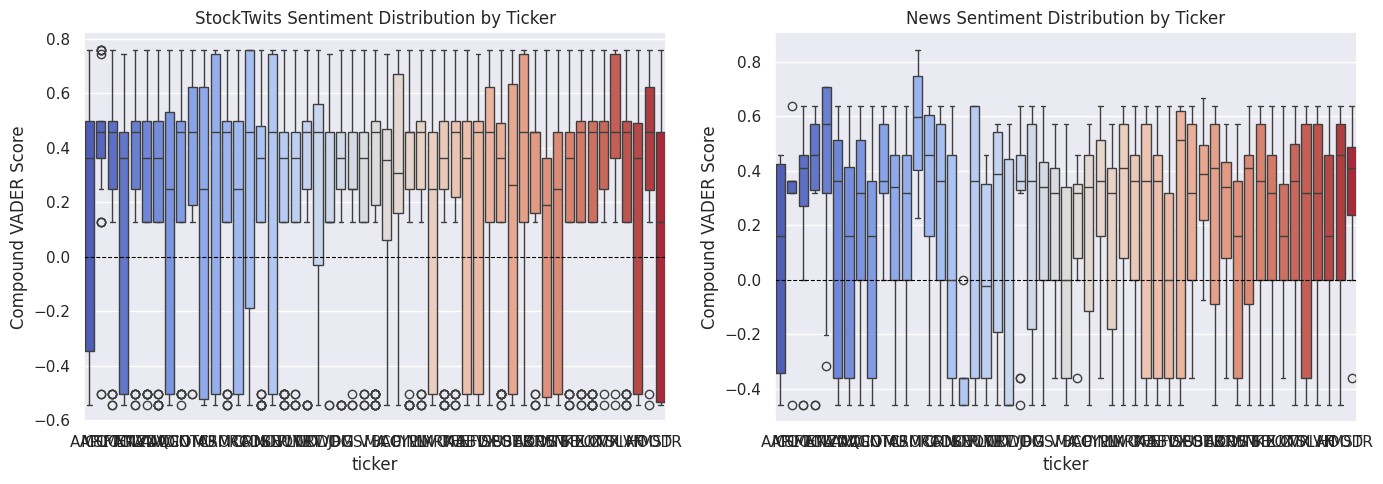

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid", palette="muted")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Reddit sentiment distribution by ticker
sns.boxplot(
    data=df_social, x="ticker", y="raw_sentiment",
    order=TICKERS, ax=axes[0], palette="coolwarm"
)
axes[0].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[0].set_title("StockTwits Sentiment Distribution by Ticker")
axes[0].set_ylabel("Compound VADER Score")

# News sentiment distribution by ticker
sns.boxplot(
    data=df_news, x="ticker", y="raw_sentiment",
    order=TICKERS, ax=axes[1], palette="coolwarm"
)
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_title("News Sentiment Distribution by Ticker")
axes[1].set_ylabel("Compound VADER Score")

plt.tight_layout()
plt.show()

## 4. Mention Velocity (Crowd Interest Signal)

In [8]:
# ── Mention velocity: recent 24h vs prior 6 days ──────────────────────────────
# A rapidly growing mention count is a crowd interest signal independent of
# sentiment direction ("any press is press").

def compute_mention_velocity(df: pd.DataFrame, ts_col: str) -> pd.Series:
    """
    Returns velocity score per ticker:
      velocity = (recent_24h_count / prior_6d_daily_avg) - 1
    Clipped to [-1, 5] to prevent outlier domination.
    """
    df = df.copy()
    df["ts"] = pd.to_datetime(df[ts_col], utc=True)
    cutoff_24h = pd.Timestamp.utcnow() - timedelta(hours=24)
    cutoff_7d  = pd.Timestamp.utcnow() - timedelta(days=7)

    velocities = {}
    for ticker in TICKERS:
        sub       = df[df["ticker"] == ticker]
        recent    = sub[sub["ts"] >= cutoff_24h]
        prior     = sub[(sub["ts"] >= cutoff_7d) & (sub["ts"] < cutoff_24h)]
        daily_avg = len(prior) / 6 if len(prior) > 0 else 1
        v = (len(recent) / daily_avg) - 1
        velocities[ticker] = float(np.clip(v, -1, 5))
    return pd.Series(velocities, name="mention_velocity")


social_velocity = compute_mention_velocity(df_social, "created_utc")
news_velocity   = compute_mention_velocity(df_news, "published_at")
# Combine: weighted average of both sources
mention_velocity = (social_velocity * 0.6 + news_velocity * 0.4).rename("mention_velocity")

print("Mention velocity (higher = growing crowd interest):")
print(mention_velocity.sort_values(ascending=False).to_string())

Mention velocity (higher = growing crowd interest):
ABNB     1.325000
MSTR     1.240000
GOOGL    0.952000
META     0.950000
ORCL     0.761290
PYPL     0.719786
LLY      0.586087
GS       0.458824
SHOP     0.323529
NVO      0.300000
CRM      0.292308
AVGO     0.275294
V        0.272414
AAPL     0.270244
SMCI     0.235294
AMZN     0.230000
XOM      0.205797
DDOG     0.200000
SNOW     0.186364
COIN     0.075325
INTC     0.040000
MA      -0.025306
NOW     -0.057143
DIS     -0.071324
F       -0.112644
NET     -0.152941
WMT     -0.169052
PFE     -0.185714
MU      -0.190756
SPOT    -0.193514
ADBE    -0.215504
TSLA    -0.258824
JPM     -0.268817
CRWD    -0.280000
RIVN    -0.280000
BAC     -0.280000
HOOD    -0.292857
PLTR    -0.303226
SBUX    -0.395789
NKE     -0.502857
CVX     -0.520000
NVDA    -0.524887
MSFT    -0.530435
QCOM    -0.566932
ABBV    -0.590000
AMD     -0.596761
COST    -0.625911
ARM     -0.653247
NFLX    -0.700000
MRNA    -0.803636
UBER    -1.000000


## 5. Price Momentum Signal

In [9]:
import yfinance as yf
from scipy import stats as scipy_stats

def fetch_price_signals(tickers: list[str], lookback: int = PRICE_LOOKBACK_DAYS) -> pd.DataFrame:
    """
    Returns per-ticker signals:
      - momentum_20d: 20-day price return
      - momentum_90d: 90-day price return
      - rsi_14:       Relative Strength Index (14-day)
      - vol_ratio:    recent 10d volatility / 30d volatility (regime signal)
    """
    end   = datetime.now()
    start = end - timedelta(days=lookback + 10)  # extra buffer for RSI warmup

    raw = yf.download(
        tickers, start=start.strftime("%Y-%m-%d"),
        end=end.strftime("%Y-%m-%d"), progress=False
    )["Close"]

    results = {}
    for t in tickers:
        try:
            prices = raw[t].dropna()

            # Returns
            mom_20 = (prices.iloc[-1] / prices.iloc[-21] - 1) if len(prices) >= 21 else 0
            mom_90 = (prices.iloc[-1] / prices.iloc[0]  - 1) if len(prices) > 1  else 0

            # RSI-14
            delta  = prices.diff().dropna()
            gains  = delta.clip(lower=0).rolling(14).mean()
            losses = (-delta).clip(lower=0).rolling(14).mean()
            rs     = gains / losses.replace(0, 1e-9)
            rsi    = (100 - 100 / (1 + rs)).iloc[-1]

            # Volatility regime
            log_ret   = np.log(prices / prices.shift(1)).dropna()
            vol_10    = log_ret.iloc[-10:].std() if len(log_ret) >= 10 else np.nan
            vol_30    = log_ret.iloc[-30:].std() if len(log_ret) >= 30 else np.nan
            vol_ratio = (vol_10 / vol_30) if (vol_30 and vol_30 > 0) else 1.0

            results[t] = {
                "momentum_20d": float(mom_20),
                "momentum_90d": float(mom_90),
                "rsi_14":       float(rsi),
                "vol_ratio":    float(vol_ratio),
                "latest_price": float(prices.iloc[-1]),
            }
        except Exception as e:
            print(f"Price fetch error for {t}: {e}")
            results[t] = {"momentum_20d": 0, "momentum_90d": 0, "rsi_14": 50,
                          "vol_ratio": 1.0, "latest_price": np.nan}

    return pd.DataFrame(results).T


print("Fetching price data from Yahoo Finance...")
df_price = fetch_price_signals(TICKERS)
print(df_price.round(4).to_string())

Fetching price data from Yahoo Finance...


/tmp/ipykernel_578/4267583162.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw = yf.download(


       momentum_20d  momentum_90d   rsi_14  vol_ratio  latest_price
AAPL         0.0702        0.1621  58.2809     1.1168      307.3400
MSFT        -0.0076        0.0477  48.0626     1.4351      416.6700
GOOGL       -0.0740        0.2031  30.3519     0.8471      368.5300
META        -0.0386       -0.0919  42.7528     1.2366      593.0000
AMZN        -0.0927        0.1806  35.5697     1.1699      246.0300
NVDA        -0.0291        0.1253  34.3337     1.1086      205.1000
AMD          0.1418        1.3481  58.5490     0.9093      466.3800
AVGO        -0.0650        0.2124  39.5053     1.5068      385.7300
QCOM         0.0700        0.5467  54.4131     1.0984      215.9400
INTC        -0.0953        1.1796  40.5475     0.6901       99.1700
MU           0.3362        1.0946  60.1170     1.3047      864.0100
ARM          0.6077        1.7573  70.8449     1.0542      342.9300
SMCI         0.2385        0.3082  68.5185     1.0527       41.6400
ORCL         0.0981        0.4367  58.0430     1

In [10]:
# ── Normalize momentum to [-1, +1] via rank-based scaling ────────────────────
# Raw % returns differ too much in magnitude across market regimes;
# rank-based normalization keeps the signal ordinal and bounded.

from scipy.stats import rankdata

def rank_normalize(series: pd.Series) -> pd.Series:
    """Convert raw values to percentile rank in [-1, +1]."""
    n = len(series)
    ranks = rankdata(series)  # 1..n
    normalized = (ranks - 1) / max(n - 1, 1) * 2 - 1  # → [-1, +1]
    return pd.Series(normalized, index=series.index)


# Combine 20d and 90d momentum; penalize overbought RSI
df_price["momentum_score"] = (
    rank_normalize(df_price["momentum_20d"]) * 0.5 +
    rank_normalize(df_price["momentum_90d"]) * 0.3 +
    # RSI: 30=oversold(+), 70=overbought(-), center at 50
    rank_normalize(50 - (df_price["rsi_14"] - 50).abs()) * 0.2
)

print("Momentum scores:")
print(df_price["momentum_score"].sort_values(ascending=False).to_string())

Momentum scores:
MU       0.760
DDOG     0.692
CRWD     0.680
ARM      0.664
AMD      0.640
ORCL     0.540
F        0.536
QCOM     0.524
SNOW     0.516
SMCI     0.456
NOW      0.384
AAPL     0.368
HOOD     0.340
GS       0.336
RIVN     0.284
CVX      0.256
LLY      0.248
SPOT     0.224
V        0.208
MSFT     0.208
JPM      0.076
XOM      0.040
ABBV    -0.004
PLTR    -0.012
CRM     -0.016
BAC     -0.024
MA      -0.032
ABNB    -0.052
NVO     -0.052
ADBE    -0.056
PFE     -0.080
AVGO    -0.080
NET     -0.100
INTC    -0.108
NVDA    -0.148
MRNA    -0.208
SHOP    -0.212
GOOGL   -0.288
META    -0.300
NKE     -0.308
AMZN    -0.320
TSLA    -0.376
COST    -0.396
DIS     -0.520
UBER    -0.592
SBUX    -0.600
NFLX    -0.672
WMT     -0.708
PYPL    -0.808
COIN    -0.944
MSTR    -0.964


## 6. Signal Aggregation & Composite Score

In [11]:
# ── Aggregate per-ticker sentiment scores ─────────────────────────────────────

def aggregate_sentiment(df: pd.DataFrame) -> pd.Series:
    """
    Volume-weighted mean sentiment per ticker.
    Uses weighted_sentiment so high-engagement posts dominate.
    Then normalizes across tickers to [-1, +1].
    """
    raw = df.groupby("ticker")["weighted_sentiment"].mean().reindex(TICKERS).fillna(0)
    return rank_normalize(raw)


social_sentiment_score = aggregate_sentiment(df_social).rename("social_sentiment")
news_sentiment_score   = aggregate_sentiment(df_news).rename("news_sentiment")
velocity_score         = rank_normalize(mention_velocity).rename("velocity_score")
momentum_score         = df_price["momentum_score"].rename("momentum_score")

# ── Combine into composite ────────────────────────────────────────────────────
df_signals = pd.DataFrame({
    "social_sentiment": social_sentiment_score,
    "news_sentiment":   news_sentiment_score,
    "velocity_score":   velocity_score,
    "momentum_score":   momentum_score,
})

df_signals["composite_score"] = (
    df_signals["social_sentiment"] * W_SOCIAL_SENTIMENT +
    df_signals["news_sentiment"]   * W_NEWS_SENTIMENT   +
    df_signals["velocity_score"]   * W_MENTION_VELOCITY +
    df_signals["momentum_score"]   * W_PRICE_MOMENTUM
)

# Assign signal
def score_to_signal(score: float) -> str:
    if score >= BUY_THRESHOLD:   return "BUY"
    if score <= SELL_THRESHOLD:  return "SELL"
    return "HOLD"


df_signals["signal"]       = df_signals["composite_score"].map(score_to_signal)
df_signals["latest_price"] = df_price["latest_price"]

df_signals = df_signals.sort_values("composite_score", ascending=False)
print(df_signals.round(3).to_string())

       social_sentiment  news_sentiment  velocity_score  momentum_score  composite_score signal  latest_price
SMCI               0.92            1.00            0.44           0.456            0.751    BUY         41.64
GOOGL              0.60            0.64            0.92          -0.288            0.496    BUY        368.53
HOOD               0.96            0.72           -0.44           0.340            0.496    BUY         82.47
ABNB               0.56            0.16            1.00          -0.052            0.426    BUY        133.54
CRM                0.52            0.40            0.60          -0.016            0.399    BUY        185.66
SHOP               0.72            0.04            0.68          -0.212            0.356    BUY        109.54
AMZN               0.28            0.96            0.40          -0.320            0.354    BUY        246.03
INTC               0.24            0.92            0.20          -0.108            0.332    BUY         99.17
MSFT      

## 7. Visualization

/tmp/ipykernel_578/3118733259.py:74: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


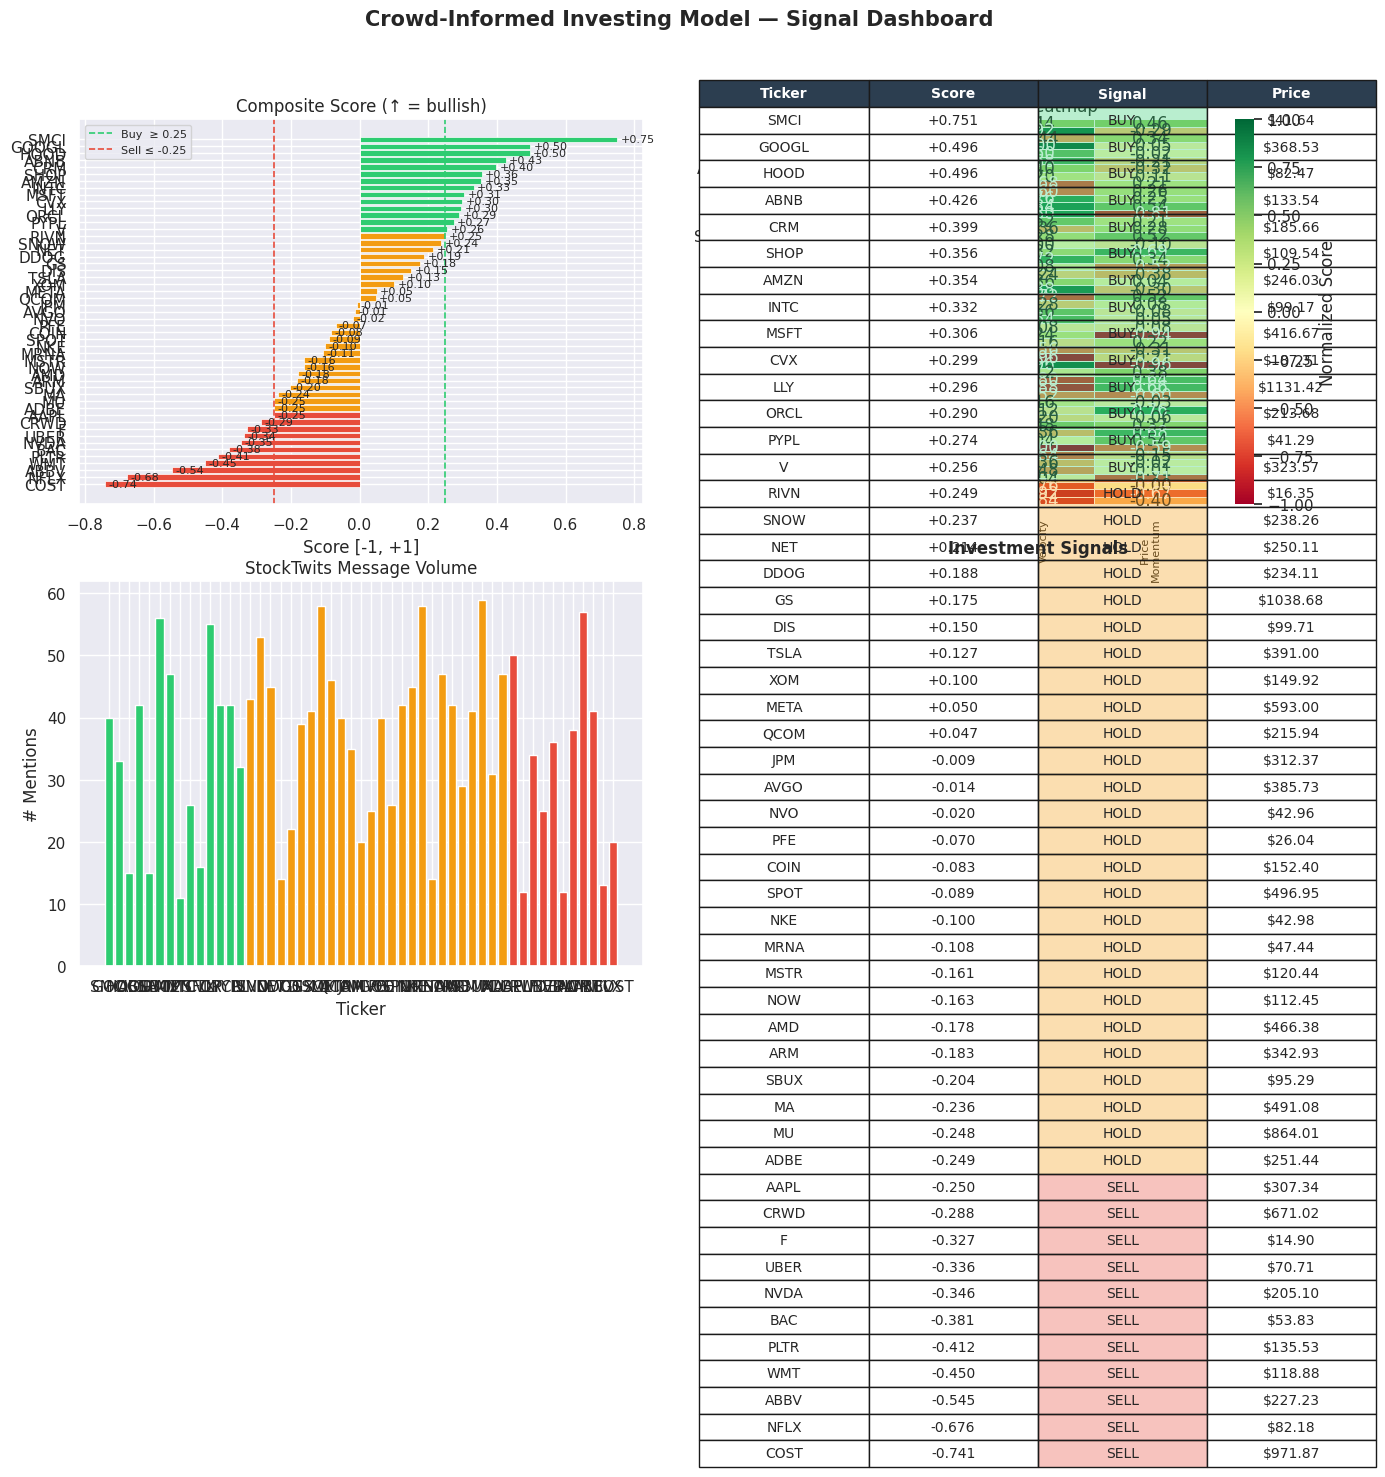

Dashboard saved to crowd_investing_dashboard.png


In [12]:
# ── Dashboard: Composite Scores ───────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle("Crowd-Informed Investing Model — Signal Dashboard", fontsize=15, fontweight="bold")

signal_colors = {"BUY": "#2ecc71", "HOLD": "#f39c12", "SELL": "#e74c3c"}
bar_colors = [signal_colors[df_signals.loc[t, "signal"]] for t in df_signals.index]

# ① Composite score bar chart
ax = axes[0, 0]
bars = ax.barh(df_signals.index[::-1], df_signals["composite_score"][::-1],
               color=bar_colors[::-1], edgecolor="white", linewidth=0.5)
ax.axvline(BUY_THRESHOLD,  color="#2ecc71", linestyle="--", linewidth=1.2, label=f"Buy  ≥ {BUY_THRESHOLD}")
ax.axvline(SELL_THRESHOLD, color="#e74c3c", linestyle="--", linewidth=1.2, label=f"Sell ≤ {SELL_THRESHOLD}")
ax.axvline(0, color="white", linewidth=0.6)
ax.set_title("Composite Score (↑ = bullish)")
ax.set_xlabel("Score [-1, +1]")
ax.legend(fontsize=8)
for bar, score in zip(bars, df_signals["composite_score"][::-1]):
    ax.text(score + 0.01, bar.get_y() + bar.get_height() / 2,
            f"{score:+.2f}", va="center", fontsize=8)

# ② Heatmap: individual signal components
ax = axes[0, 1]
cols = ["social_sentiment", "news_sentiment", "velocity_score", "momentum_score"]
heatmap_data = df_signals[cols].astype(float)
sns.heatmap(
    heatmap_data, ax=ax, cmap="RdYlGn", center=0,
    vmin=-1, vmax=1, annot=True, fmt=".2f", linewidths=0.4,
    cbar_kws={"label": "Normalized Score"}
)
ax.set_title("Signal Component Heatmap")
ax.set_xticklabels(["StockTwits\nSentiment", "News\nSentiment",
                    "Mention\nVelocity", "Price\nMomentum"], fontsize=8)

# ③ Reddit mention volume by ticker
ax = axes[1, 0]
mention_counts = df_social.groupby("ticker").size().reindex(df_signals.index)
ax.bar(mention_counts.index, mention_counts.values,
       color=[signal_colors[df_signals.loc[t, "signal"]] for t in mention_counts.index],
       edgecolor="white")
ax.set_title("StockTwits Message Volume")
ax.set_ylabel("# Mentions")
ax.set_xlabel("Ticker")

# ④ Signal summary table
ax = axes[1, 1]
ax.axis("off")
table_data = []
for ticker in df_signals.index:
    row = df_signals.loc[ticker]
    table_data.append([
        ticker,
        f"{row['composite_score']:+.3f}",
        row["signal"],
        f"${row['latest_price']:.2f}" if pd.notna(row["latest_price"]) else "N/A",
    ])
tbl = ax.table(
    cellText=table_data,
    colLabels=["Ticker", "Score", "Signal", "Price"],
    cellLoc="center", loc="center"
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.6)
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor("#2c3e50")
        cell.set_text_props(color="white", fontweight="bold")
    elif col == 2 and row > 0:
        sig = table_data[row - 1][2]
        cell.set_facecolor(signal_colors[sig] + "55")  # alpha
ax.set_title("Investment Signals", fontweight="bold", pad=20)

plt.tight_layout()
plt.savefig("crowd_investing_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("Dashboard saved to crowd_investing_dashboard.png")

## 8. Historical Evaluation

Three complementary tests using **Wikipedia pageviews** as a real historical
crowd-attention proxy (academic precedent: Preis, Moat & Stanley 2013 —
*Quantifying Trading Behavior in Financial Markets Using Google Trends*).

1. **Information Coefficient (IC)** — weekly correlation between signal rank and forward return
2. **Quintile Analysis** — cumulative return of top-2 vs bottom-2 tickers by signal score
3. **Hit Rate** — % of weeks where the highest-signal ticker beats the lowest-signal ticker

In [13]:
import requests
import yfinance as yf
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from scipy.stats import spearmanr, ttest_1samp
import time
import warnings
warnings.filterwarnings("ignore")

WIKI_ARTICLES = {
    "AAPL":  "Apple_Inc.",
    "MSFT":  "Microsoft",
    "NVDA":  "Nvidia",
    "TSLA":  "Tesla,_Inc.",
    "GOOGL": "Alphabet_Inc.",
    "AMZN":  "Amazon_(company)",
    "META":  "Meta_Platforms",
    "AMD":   "Advanced_Micro_Devices",
    "AVGO":  "Broadcom_Inc.",
    "QCOM":  "Qualcomm",
    "INTC":  "Intel",
    "MU":    "Micron_Technology",
    "ARM":   "Arm_Holdings",
    "SMCI":  "Super_Micro_Computer",
    "ORCL":  "Oracle_Corporation",
    "CRM":   "Salesforce",
    "ADBE":  "Adobe_Inc.",
    "NOW":   "ServiceNow",
    "SNOW":  "Snowflake_Inc.",
    "PLTR":  "Palantir_Technologies",
    "NET":   "Cloudflare",
    "CRWD":  "CrowdStrike",
    "DDOG":  "Datadog",
    "JPM":   "JPMorgan_Chase",
    "GS":    "Goldman_Sachs",
    "V":     "Visa_Inc.",
    "MA":    "Mastercard",
    "COIN":  "Coinbase",
    "BAC":   "Bank_of_America",
    "PYPL":  "PayPal",
    "LLY":   "Eli_Lilly_and_Company",
    "NVO":   "Novo_Nordisk",
    "MRNA":  "Moderna",
    "PFE":   "Pfizer",
    "ABBV":  "AbbVie",
    "NFLX":  "Netflix",
    "DIS":   "The_Walt_Disney_Company",
    "SPOT":  "Spotify",
    "UBER":  "Uber",
    "SHOP":  "Shopify",
    "ABNB":  "Airbnb",
    "COST":  "Costco",
    "WMT":   "Walmart",
    "NKE":   "Nike,_Inc.",
    "SBUX":  "Starbucks",
    "XOM":   "ExxonMobil",
    "CVX":   "Chevron_Corporation",
    "RIVN":  "Rivian",
    "F":     "Ford_Motor_Company",
    "HOOD":  "Robinhood_Markets",
    "MSTR":  "MicroStrategy",
}

end     = datetime.now()
start   = end - timedelta(days=730)
start_s = start.strftime("%Y%m%d")
end_s   = end.strftime("%Y%m%d")

# ── 1. Wikipedia daily pageviews ──────────────────────────────────────────────
print(f"Fetching Wikipedia pageviews for {len(WIKI_ARTICLES)} tickers...")
wiki_frames = {}
for ticker, article in WIKI_ARTICLES.items():
    url = (
        f"https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article"
        f"/en.wikipedia/all-access/user/{article}/daily/{start_s}/{end_s}"
    )
    try:
        resp  = requests.get(url, headers={"User-Agent": "crowd_investing/0.1"}, timeout=15)
        resp.raise_for_status()
        items = resp.json().get("items", [])
        wiki_frames[ticker] = pd.Series(
            {pd.to_datetime(x["timestamp"], format="%Y%m%d00"): x["views"] for x in items},
            name=ticker
        )
    except Exception as e:
        print(f"  {ticker}: FAILED — {e}")
    time.sleep(0.25)

wiki_daily = pd.DataFrame(wiki_frames)
wiki_daily.index = pd.DatetimeIndex(wiki_daily.index).tz_localize(None)
wiki_weekly = wiki_daily.resample("W").sum()
print(f"  Got wiki data for {len(wiki_frames)}/{len(WIKI_ARTICLES)} tickers")

# ── 2. Daily prices → weekly ─────────────────────────────────────────────────
print(f"Fetching 2-year daily prices for {len(TICKERS)} tickers...")
prices_daily = yf.download(
    TICKERS,
    start=start.strftime("%Y-%m-%d"),
    end=end.strftime("%Y-%m-%d"),
    interval="1d", progress=False
)["Close"].ffill().dropna(how="all")

prices_daily.index = pd.DatetimeIndex(
    prices_daily.index.tz_localize(None) if prices_daily.index.tz else prices_daily.index
).normalize()
prices_weekly = prices_daily.resample("W").last()

# ── 3. Align indexes ─────────────────────────────────────────────────────────
wiki_weekly.index  = wiki_weekly.index.normalize()
prices_weekly.index = prices_weekly.index.normalize()

common_idx = prices_weekly.index.intersection(wiki_weekly.index)
if len(common_idx) == 0:
    print("Direct intersection empty — falling back to ISO year+week join...")
    prices_weekly["_yw"] = prices_weekly.index.to_series().apply(
        lambda d: (d.isocalendar()[0], d.isocalendar()[1]))
    wiki_weekly["_yw"] = wiki_weekly.index.to_series().apply(
        lambda d: (d.isocalendar()[0], d.isocalendar()[1]))
    merged = prices_weekly.reset_index().merge(
        wiki_weekly.reset_index(), on="_yw", suffixes=("_p", "_w")
    ).set_index("Date")
    valid_tickers = [t for t in TICKERS if t in merged.columns]
    prices_w = merged[valid_tickers]
    wiki_w   = merged[[f"{t}_w" for t in valid_tickers if f"{t}_w" in merged.columns]]
    wiki_w.columns = [c[:-2] for c in wiki_w.columns]
else:
    valid_tickers = [t for t in TICKERS if t in prices_weekly.columns]
    prices_w = prices_weekly.loc[common_idx, valid_tickers]
    wiki_w   = wiki_weekly.loc[common_idx].reindex(columns=valid_tickers)

weekly_ret = prices_w.pct_change().shift(-1)

print(f"\nFinal: {len(prices_w)} weeks x {len(valid_tickers)} tickers")
wiki_w.tail(3).fillna(0).astype(int)

Fetching Wikipedia pageviews for 51 tickers...
  INTC: FAILED — 429 Client Error: Too Many Requests for url: https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article/en.wikipedia/all-access/user/Intel/daily/20240608/20260608
  MU: FAILED — 429 Client Error: Too Many Requests for url: https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article/en.wikipedia/all-access/user/Micron_Technology/daily/20240608/20260608
  ARM: FAILED — 429 Client Error: Too Many Requests for url: https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article/en.wikipedia/all-access/user/Arm_Holdings/daily/20240608/20260608
  SMCI: FAILED — 429 Client Error: Too Many Requests for url: https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article/en.wikipedia/all-access/user/Super_Micro_Computer/daily/20240608/20260608
  ORCL: FAILED — 429 Client Error: Too Many Requests for url: https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article/en.wikipedia/all-access/user/Oracle_Corporation/daily/20

,AAPL,MSFT,GOOGL,META,AMZN,NVDA,AMD,AVGO,QCOM,INTC,...,WMT,NKE,SBUX,XOM,CVX,TSLA,RIVN,F,HOOD,MSTR
2026-05-24,41369,34775,23460,27980,38289,67816,1139,551,7164,0,...,0,0,0,0,0,26193,0,0,0,0
2026-05-31,39526,36676,21862,22993,38817,57581,1195,534,7918,0,...,0,0,0,0,0,24857,0,0,0,0
2026-06-07,41278,35026,23681,21666,37850,64841,1207,960,8626,0,...,0,0,0,0,0,25569,0,0,0,0


In [14]:
from scipy.stats import rankdata

def sector_neutral_rank(raw_scores, sectors, available_tickers):
    """
    Rank tickers within each sector, then return scores normalised to [-1, +1].
    Tickers in single-member sectors get 0 (neutral — can't rank alone).
    Any ticker not in SECTORS falls into a catch-all "Other" bucket.
    """
    result = pd.Series(0.0, index=raw_scores.index)

    # Build reverse map: ticker → sector
    ticker_sector = {t: s for s, tks in sectors.items() for t in tks}
    assigned = set(ticker_sector.keys())

    # Group tickers (only those present in available_tickers)
    buckets = {}
    for t in available_tickers:
        s = ticker_sector.get(t, "Other")
        buckets.setdefault(s, []).append(t)

    for sec, members in buckets.items():
        present = [t for t in members
                   if t in raw_scores.index and pd.notna(raw_scores[t])]
        if len(present) < 2:
            continue   # can't rank 0 or 1 ticker — leave at 0
        vals  = raw_scores[present].fillna(0)
        ranks = rankdata(vals)
        n     = len(present)
        normed = (ranks - 1) / max(n - 1, 1) * 2 - 1
        for t, score in zip(present, normed):
            result[t] = score
    return result

# Wikipedia attention velocity: z-score vs 4-week rolling baseline
wiki_vel = (
    (wiki_w - wiki_w.rolling(4).mean()) /
    (wiki_w.rolling(4).std().replace(0, 1))
).clip(-3, 3)

# 4-week trailing price momentum
price_mom = prices_w.pct_change(4)

# ── Contrarian sector-neutral composite ──────────────────────────────────────
# Negate both inputs: LOW attention + LOW momentum within sector = under-owned
avail = [t for t in valid_tickers if t in wiki_w.columns]
composite = pd.DataFrame(index=prices_w.index, columns=avail, dtype=float)

for date in prices_w.index:
    try:
        raw = (-wiki_vel.loc[date] * 0.6) + (-price_mom.loc[date] * 0.4)
        composite.loc[date] = sector_neutral_rank(raw, SECTORS, avail)
    except KeyError:
        continue

composite = composite.dropna(how="all").dropna(axis=1, how="all")
fwd_ret   = weekly_ret.reindex(index=composite.index,
                                columns=composite.columns)

print("Sector-neutral contrarian composite built.")
print(f"Universe: {len(composite.columns)} tickers | History: {len(composite)} weeks")
print("\nSector coverage:")
ticker_sector = {t: s for s, tks in SECTORS.items() for t in tks}
sec_counts = {}
for t in composite.columns:
    s = ticker_sector.get(t, "Other")
    sec_counts[s] = sec_counts.get(s, 0) + 1
for s, n in sec_counts.items():
    print(f"  {s:<22} {n} tickers")
composite.tail(3).round(2)

Sector-neutral contrarian composite built.
Universe: 51 tickers | History: 104 weeks

Sector coverage:
  Mega-cap Tech          5 tickers
  Semiconductors         8 tickers
  Software/Cloud         9 tickers
  Finance                5 tickers
  Fintech                3 tickers
  Healthcare             5 tickers
  Consumer/Ent           6 tickers
  Retail                 4 tickers
  Energy                 2 tickers
  Auto/EV                3 tickers
  Crowd                  1 tickers


,AAPL,MSFT,GOOGL,META,AMZN,NVDA,AMD,AVGO,QCOM,INTC,...,WMT,NKE,SBUX,XOM,CVX,TSLA,RIVN,F,HOOD,MSTR
2026-05-24,1.0,0.0,-0.5,-1.0,0.5,-1.00,-0.33,1.0,0.33,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2026-05-31,1.0,-1.0,0.0,0.5,-0.5,0.33,-1.00,1.0,-0.33,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2026-06-07,-0.5,0.5,-1.0,1.0,0.0,1.00,0.33,-1.0,-0.33,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [15]:
# ── 1. Information Coefficient (IC) ─────────────────────────────────────────
ics = []
for date in composite.index:
    sig   = composite.loc[date]
    ret   = fwd_ret.loc[date]
    valid = sig.notna() & ret.notna()
    if valid.sum() >= 10:
        ic, _ = spearmanr(sig[valid], ret[valid])
        ics.append({"date": date, "ic": ic})

df_ic   = pd.DataFrame(ics).set_index("date")
mean_ic = df_ic["ic"].mean()
icir    = df_ic["ic"].mean() / df_ic["ic"].std()
t_stat, p_val = ttest_1samp(df_ic["ic"].dropna(), 0)

print("=== Sector-Neutral Contrarian Backtest ===")
print(f"Mean IC:  {mean_ic:+.4f}  (>0 = predictive | >0.05 = strong)")
print(f"ICIR:     {icir:+.4f}  (>0.5 = investable)")
print(f"t-stat:   {t_stat:+.4f}  p-value: {p_val:.4f}  (<0.05 = significant)")
print(f"IC > 0:   {(df_ic["ic"] > 0).mean():.1%} of weeks")

# ── 2. Quintile Analysis — top vs bottom 20% ─────────────────────────────────
Q = max(int(len(composite.columns) * 0.20), 2)
top_ret, bot_ret, dates_q = [], [], []
for date in composite.index:
    sig = composite.loc[date]
    ret = fwd_ret.loc[date].dropna()
    if len(ret) < Q * 2:
        continue
    top_ret.append(ret.reindex(sig.nlargest(Q).index).mean())
    bot_ret.append(ret.reindex(sig.nsmallest(Q).index).mean())
    dates_q.append(date)

df_q    = pd.DataFrame({"top_q": top_ret, "bot_q": bot_ret}, index=dates_q)
df_q["spread"] = df_q["top_q"] - df_q["bot_q"]
cum_top = (1 + df_q["top_q"]).cumprod()
cum_bot = (1 + df_q["bot_q"]).cumprod()

print(f"\nQuintile: top {Q} / bottom {Q} of {len(composite.columns)} tickers")
print(f"Top quintile 2yr return:    {cum_top.iloc[-1]-1:+.1%}")
print(f"Bottom quintile 2yr return: {cum_bot.iloc[-1]-1:+.1%}")
print(f"Spread annualised:          {df_q["spread"].mean() * 52:+.1%}")

# ── 3. Per-sector IC breakdown ────────────────────────────────────────────────
print("\n=== IC by Sector ===")
ticker_sector = {t: s for s, tks in SECTORS.items() for t in tks}
for sector in SECTORS:
    sec_tickers = [t for t in composite.columns
                   if ticker_sector.get(t) == sector]
    if len(sec_tickers) < 2:
        continue
    sec_ics = []
    for date in composite.index:
        sig   = composite.loc[date, sec_tickers]
        ret   = fwd_ret.loc[date].reindex(sec_tickers)
        valid = sig.notna() & ret.notna()
        if valid.sum() >= 2:
            ic, _ = spearmanr(sig[valid], ret[valid])
            sec_ics.append(ic)
    clean = [x for x in sec_ics if not np.isnan(x)]
    if clean:
        m = np.mean(clean)
        bar = "█" * max(int(abs(m) * 200), 0)
        sign = "+" if m >= 0 else "-"
        print(f"  {sector:<22} IC={m:+.4f}  {sign}{bar}")

# ── 4. Hit Rate ───────────────────────────────────────────────────────────────
hit_weeks, total_weeks = 0, 0
for date in composite.index:
    sig = composite.loc[date]
    ret = fwd_ret.loc[date].dropna()
    if len(ret) < 2:
        continue
    if ret.get(sig.idxmax(), np.nan) > ret.get(sig.idxmin(), np.nan):
        hit_weeks += 1
    total_weeks += 1

hit_rate = hit_weeks / total_weeks if total_weeks else 0
print(f"\nHit rate: {hit_rate:.1%}  ({hit_weeks}/{total_weeks} weeks)")
print(f"Edge vs random: {hit_rate - 0.5:+.1%}")

=== Sector-Neutral Contrarian Backtest ===
Mean IC:  +0.0153  (>0 = predictive | >0.05 = strong)
ICIR:     +0.1438  (>0.5 = investable)
t-stat:   +1.4311  p-value: 0.1556  (<0.05 = significant)
IC > 0:   50.5% of weeks

Quintile: top 10 / bottom 10 of 51 tickers
Top quintile 2yr return:    +147.9%
Bottom quintile 2yr return: +90.2%
Spread annualised:          +13.0%

=== IC by Sector ===
  Mega-cap Tech          IC=-0.0172  -███
  Semiconductors         IC=+0.0488  +█████████

Hit rate: 43.7%  (45/103 weeks)
Edge vs random: -6.3%


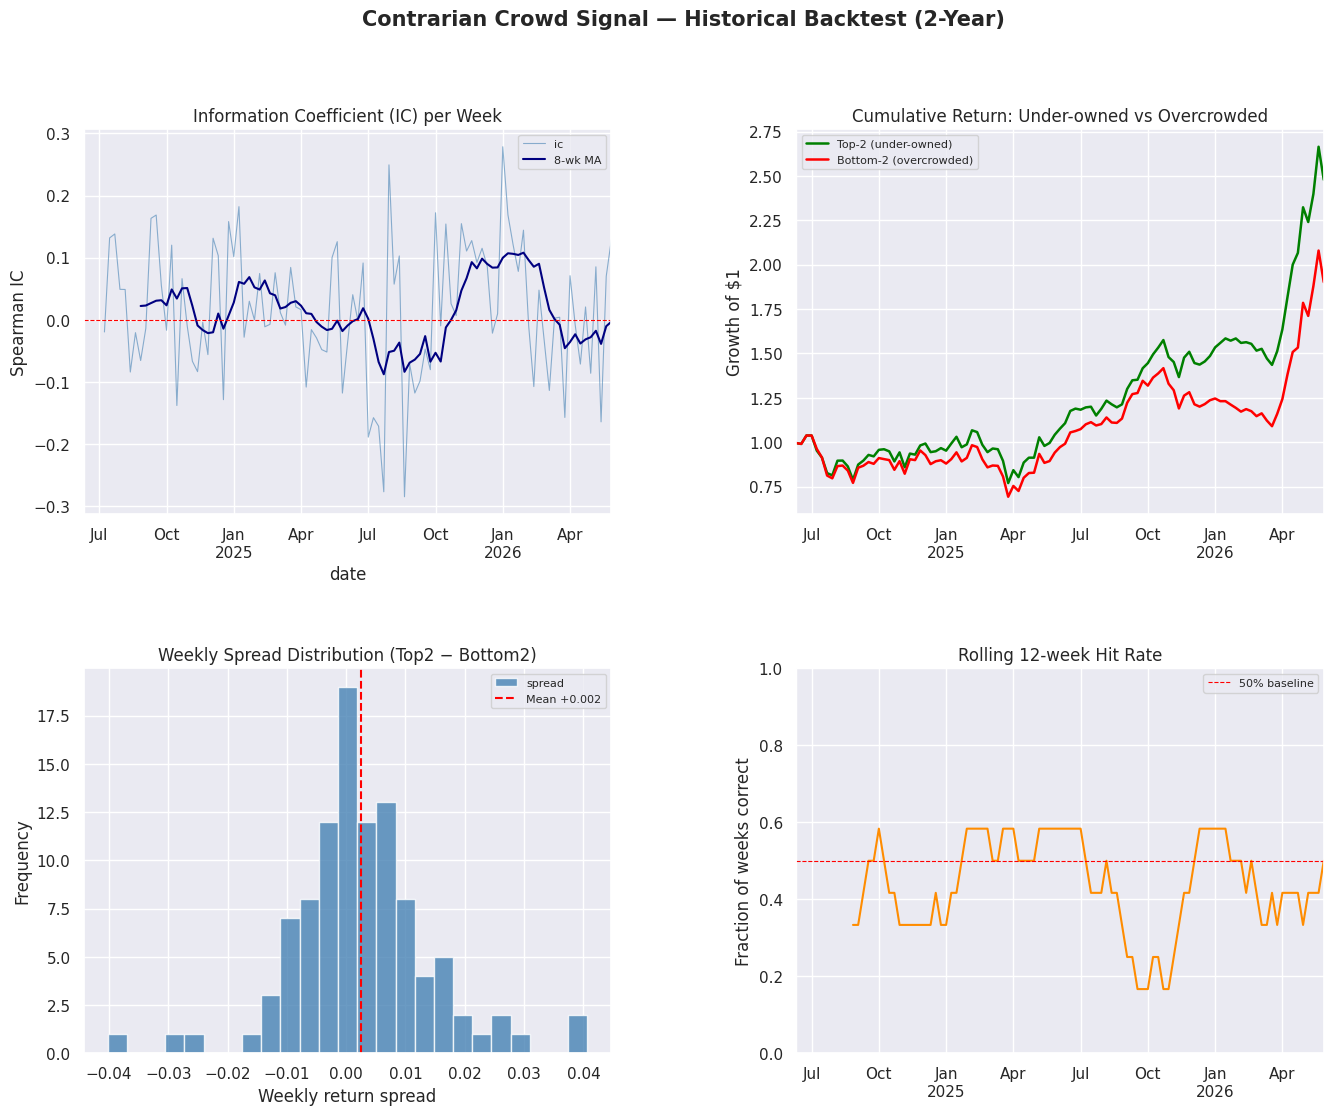

Backtest chart saved.


In [16]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(16, 12))
fig.suptitle('Contrarian Crowd Signal — Historical Backtest (2-Year)', fontsize=15, fontweight='bold')
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

# ── IC over time ──────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
df_ic['ic'].plot(ax=ax1, color='steelblue', alpha=0.6, linewidth=0.8)
df_ic['ic'].rolling(8).mean().plot(ax=ax1, color='navy', linewidth=1.5, label='8-wk MA')
ax1.axhline(0, color='red', linewidth=0.8, linestyle='--')
ax1.set_title('Information Coefficient (IC) per Week')
ax1.set_ylabel('Spearman IC')
ax1.legend(fontsize=8)

# ── Cumulative returns ────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
cum_top.plot(ax=ax2, color='green',  linewidth=1.8, label='Top-2 (under-owned)')
cum_bot.plot(ax=ax2, color='red',    linewidth=1.8, label='Bottom-2 (overcrowded)')
ax2.set_title('Cumulative Return: Under-owned vs Overcrowded')
ax2.set_ylabel('Growth of $1')
ax2.legend(fontsize=8)

# ── Weekly spread distribution ────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
df_q['spread'].plot.hist(ax=ax3, bins=25, color='steelblue', edgecolor='white', alpha=0.8)
ax3.axvline(df_q['spread'].mean(), color='red', linestyle='--',
            label=f'Mean {df_q["spread"].mean():+.3f}')
ax3.set_title('Weekly Spread Distribution (Top2 − Bottom2)')
ax3.set_xlabel('Weekly return spread')
ax3.legend(fontsize=8)

# ── Rolling hit rate ─────────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
roll_hits = pd.Series(
    [(composite.loc[d].idxmax() != composite.loc[d].idxmin()) and
     (fwd_ret.loc[d].get(composite.loc[d].idxmax(), np.nan) >
      fwd_ret.loc[d].get(composite.loc[d].idxmin(), np.nan))
     for d in composite.index
     if fwd_ret.loc[d].dropna().__len__() >= 2],
    index=[d for d in composite.index if fwd_ret.loc[d].dropna().__len__() >= 2]
).astype(float)
roll_hits.rolling(12).mean().plot(ax=ax4, color='darkorange', linewidth=1.5)
ax4.axhline(0.5, color='red', linewidth=0.8, linestyle='--', label='50% baseline')
ax4.set_title('Rolling 12-week Hit Rate')
ax4.set_ylabel('Fraction of weeks correct')
ax4.set_ylim(0, 1)
ax4.legend(fontsize=8)

plt.savefig('crowd_investing_backtest.png', dpi=150, bbox_inches='tight')
plt.show()
print('Backtest chart saved.')

## 9. Final Recommendations

In [17]:
# ── Print final investment signals ────────────────────────────────────────────
print("=" * 60)
print(f"  CROWD-INFORMED INVESTING MODEL — {datetime.now().strftime('%Y-%m-%d %H:%M')}")
print("=" * 60)
print(f"{'Ticker':<8} {'Score':>8} {'Signal':<7} {'Social':>9} {'News':>9} {'Velocity':>10} {'Momentum':>10}")
print("-" * 65)

for ticker in df_signals.index:
    r = df_signals.loc[ticker]
    sig_color = {"BUY": "\033[92m", "HOLD": "\033[93m", "SELL": "\033[91m"}
    reset = "\033[0m"
    color = sig_color.get(r["signal"], "")
    print(
        f"{ticker:<8} {r['composite_score']:>+8.3f} "
        f"{color}{r['signal']:<7}{reset} "
        f"{r['social_sentiment']:>+9.3f} "
        f"{r['news_sentiment']:>+9.3f} "
        f"{r['velocity_score']:>+10.3f} "
        f"{r['momentum_score']:>+10.3f}"
    )

print("=" * 60)
print("\nNOTE: This model is for research and educational purposes only.")
print("Past performance does not guarantee future results.")
print("Always conduct independent due diligence before investing.")

  CROWD-INFORMED INVESTING MODEL — 2026-06-08 05:21
Ticker      Score Signal     Social      News   Velocity   Momentum
-----------------------------------------------------------------
SMCI       +0.751 BUY        +0.920    +1.000     +0.440     +0.456
GOOGL      +0.496 BUY        +0.600    +0.640     +0.920     -0.288
HOOD       +0.496 BUY        +0.960    +0.720     -0.440     +0.340
ABNB       +0.426 BUY        +0.560    +0.160     +1.000     -0.052
CRM        +0.399 BUY        +0.520    +0.400     +0.600     -0.016
SHOP       +0.356 BUY        +0.720    +0.040     +0.680     -0.212
AMZN       +0.354 BUY        +0.280    +0.960     +0.400     -0.320
INTC       +0.332 BUY        +0.240    +0.920     +0.200     -0.108
MSFT       +0.306 BUY        +0.800    +0.480     -0.680     +0.208
CVX        +0.299 BUY        +0.880    +0.240     -0.600     +0.256
LLY        +0.296 BUY        +0.640    -0.520     +0.760     +0.248
ORCL       +0.290 BUY        -0.560    +0.840     +0.840     +0.54

## 9. Additional Signals

Seven orthogonal signals combined into a single conviction score:

| # | Signal | Rationale |
|---|---|---|
| 1 | Options Put/Call Ratio | High fear (P/C > 1) = contrarian buy |
| 2 | Short Interest | High short % = squeeze potential |
| 3 | Congressional Trades | STOCK Act filings — informed capital |
| 4 | SEC Form 4 Insider Buys | Cluster buys = inside conviction |
| 5 | 10-Q Linguistic Shift | Less hedging language = rising confidence |
| 6 | GitHub Activity | Commit velocity = R&D proxy (tech stocks) |
| 7 | Contrarian Crowd | Wikipedia attention fade (from Section 8) |

In [18]:
import yfinance as yf
import pandas as pd
import numpy as np
import requests
import time
from datetime import datetime, timedelta

print('=== Signal 1: Options Put/Call Ratio ===')
print('High P/C = fear/bearish crowd = contrarian BUY | Low P/C = euphoria = FADE\n')

def fetch_options_signal():
    rows = []
    for ticker in TICKERS:
        try:
            t    = yf.Ticker(ticker)
            exps = t.options
            if not exps:
                raise ValueError('no options data')
            total_call, total_put = 0, 0
            for exp in exps[:2]:   # nearest 2 expirations
                chain = t.option_chain(exp)
                total_call += chain.calls['volume'].fillna(0).sum()
                total_put  += chain.puts['volume'].fillna(0).sum()
            pc = total_put / max(total_call, 1)
            rows.append({'ticker': ticker, 'call_vol': int(total_call),
                         'put_vol': int(total_put), 'put_call_ratio': round(pc, 4)})
            print(f'  {ticker}: P/C = {pc:.3f}  (calls={int(total_call):,}  puts={int(total_put):,})')
            time.sleep(0.3)
        except Exception as e:
            print(f'  {ticker}: error — {e}')
            rows.append({'ticker': ticker, 'call_vol': None,
                         'put_vol': None, 'put_call_ratio': None})
    return pd.DataFrame(rows).set_index('ticker')

df_options = fetch_options_signal()
pc_vals = df_options['put_call_ratio'].dropna()
# Equity market average P/C ~ 0.7; above that = fear = contrarian positive
df_options['options_signal'] = (
    (df_options['put_call_ratio'] - 0.7) / max(pc_vals.std(), 0.01)
).clip(-2, 2).fillna(0)
df_options[['put_call_ratio', 'options_signal']].round(3)

=== Signal 1: Options Put/Call Ratio ===
High P/C = fear/bearish crowd = contrarian BUY | Low P/C = euphoria = FADE

  AAPL: P/C = 0.502  (calls=162,616  puts=81,620)
  MSFT: P/C = 0.486  (calls=77,814  puts=37,800)
  GOOGL: P/C = 0.526  (calls=43,236  puts=22,739)
  META: P/C = 1.097  (calls=58,926  puts=64,616)
  AMZN: P/C = 1.033  (calls=80,455  puts=83,077)
  NVDA: P/C = 0.628  (calls=514,790  puts=323,176)
  AMD: P/C = 1.119  (calls=120,141  puts=134,413)
  AVGO: P/C = 1.204  (calls=54,112  puts=65,157)
  QCOM: P/C = 0.620  (calls=45,418  puts=28,161)
  INTC: P/C = 0.933  (calls=162,899  puts=151,910)
  MU: P/C = 1.775  (calls=190,445  puts=337,984)
  ARM: P/C = 1.422  (calls=18,237  puts=25,934)
  SMCI: P/C = 0.388  (calls=109,440  puts=42,436)
  ORCL: P/C = 0.791  (calls=79,485  puts=62,857)
  CRM: P/C = 0.575  (calls=18,020  puts=10,366)
  ADBE: P/C = 0.493  (calls=14,256  puts=7,032)
  NOW: P/C = 1.001  (calls=41,665  puts=41,713)
  SNOW: P/C = 0.690  (calls=14,245  puts=9,825

,put_call_ratio,options_signal
ticker,,
AAPL,0.502,-0.394
MSFT,0.486,-0.426
GOOGL,0.526,-0.347
META,1.097,0.790
AMZN,1.033,0.662
NVDA,0.628,-0.144
AMD,1.119,0.834
AVGO,1.204,1.004
QCOM,0.620,-0.159


In [19]:
print('=== Signal 2: Short Interest ===')
print('High short % of float + low crowd attention = potential squeeze setup\n')

def fetch_short_signal():
    rows = []
    for ticker in TICKERS:
        try:
            info    = yf.Ticker(ticker).info
            si_pct  = info.get('shortPercentOfFloat')
            si_days = info.get('shortRatio')
            rows.append({'ticker': ticker,
                         'short_pct_float': si_pct,
                         'days_to_cover':   si_days})
            pct_str = f'{si_pct:.1%}' if si_pct else 'N/A'
            day_str = f'{si_days:.1f}d' if si_days else 'N/A'
            print(f'  {ticker}: {pct_str} of float shorted | {day_str} to cover')
            time.sleep(0.4)
        except Exception as e:
            print(f'  {ticker}: error — {e}')
            rows.append({'ticker': ticker, 'short_pct_float': None, 'days_to_cover': None})
    return pd.DataFrame(rows).set_index('ticker')

df_short = fetch_short_signal()
si = df_short['short_pct_float'].dropna()
df_short['short_signal'] = ((si - si.mean()) / max(si.std(), 0.001)).clip(-2, 2)
df_short[['short_pct_float', 'days_to_cover', 'short_signal']].round(3)

=== Signal 2: Short Interest ===
High short % of float + low crowd attention = potential squeeze setup

  AAPL: 0.9% of float shorted | 2.8d to cover
  MSFT: 1.0% of float shorted | 2.1d to cover
  GOOGL: 1.4% of float shorted | 3.0d to cover
  META: 1.5% of float shorted | 2.1d to cover
  AMZN: 1.1% of float shorted | 2.3d to cover
  NVDA: 1.3% of float shorted | 1.9d to cover
  AMD: 2.8% of float shorted | 1.0d to cover
  AVGO: 1.1% of float shorted | 2.7d to cover
  QCOM: 5.4% of float shorted | 1.9d to cover
  INTC: 2.8% of float shorted | 0.9d to cover
  MU: 3.1% of float shorted | 0.8d to cover
  ARM: 13.3% of float shorted | 1.7d to cover
  SMCI: 18.0% of float shorted | 2.2d to cover
  ORCL: 2.1% of float shorted | 1.3d to cover
  CRM: 8.8% of float shorted | 5.0d to cover
  ADBE: 5.2% of float shorted | 3.7d to cover
  NOW: 5.6% of float shorted | 2.1d to cover
  SNOW: 5.8% of float shorted | 2.8d to cover
  PLTR: 3.3% of float shorted | 1.6d to cover
  NET: 3.2% of float shor

,short_pct_float,days_to_cover,short_signal
ticker,,,
AAPL,0.010,2.84,-0.740
MSFT,0.010,2.15,-0.720
GOOGL,0.014,3.02,-0.638
META,0.015,2.07,-0.626
AMZN,0.011,2.28,-0.716
NVDA,0.013,1.92,-0.667
AMD,0.028,0.97,-0.338
AVGO,0.012,2.70,-0.696
QCOM,0.054,1.88,0.245


In [20]:
print("=== Signal 3: Analyst Revision Momentum ===")
print("Net upgrades vs downgrades in last 90 days — analyst consensus shift\n")

def fetch_analyst_signal(lookback_days=90):
    cutoff = pd.Timestamp.now(tz="UTC") - pd.Timedelta(days=lookback_days)
    rows = []
    for ticker in TICKERS:
        try:
            t  = yf.Ticker(ticker)
            ud = t.upgrades_downgrades
            if ud is None or ud.empty:
                raise ValueError("no data")
            # Normalise index to UTC-aware
            if ud.index.tz is None:
                ud.index = ud.index.tz_localize("UTC")
            recent = ud[ud.index >= cutoff]
            upgrades   = recent["Action"].str.lower().str.contains(
                "up|strong buy|buy|outperform|overweight|positive").sum()
            downgrades = recent["Action"].str.lower().str.contains(
                "down|sell|underperform|underweight|negative|reduce").sum()
            net = int(upgrades) - int(downgrades)
            print(f"  {ticker}: {int(upgrades)} upgrades | {int(downgrades)} downgrades → net {net:+d}")
            rows.append({"ticker": ticker, "upgrades": int(upgrades),
                         "downgrades": int(downgrades), "net_revisions": net})
        except Exception as e:
            print(f"  {ticker}: error — {e}")
            rows.append({"ticker": ticker, "upgrades": 0,
                         "downgrades": 0, "net_revisions": 0})
        time.sleep(0.3)

    df = pd.DataFrame(rows).set_index("ticker")
    net = df["net_revisions"].astype(float)
    std = net.std()
    df["analyst_signal"] = ((net - net.mean()) / max(std, 1)).clip(-2, 2)
    return df

df_analyst = fetch_analyst_signal()
df_analyst[["upgrades", "downgrades", "net_revisions", "analyst_signal"]].sort_values(
    "net_revisions", ascending=False
)

In [21]:
import xml.etree.ElementTree as ET, re as _re

print("=== Signal 4: SEC Form 4 — Insider Purchase Clusters ===")
print("Open-market purchases (code P) >$50K in last 90 days\n")

EDGAR_HDR = {"User-Agent": "crowd_investing research@example.com"}

def get_cik_map():
    resp = requests.get("https://www.sec.gov/files/company_tickers.json",
                        headers=EDGAR_HDR, timeout=15)
    return {v["ticker"].upper(): str(v["cik_str"]).zfill(10)
            for v in resp.json().values()}

def parse_form4_xml(xml_text):
    """Return (buys, sells) counting open-market P/S transactions >$50K."""
    buys, sells = 0, 0
    try:
        root = ET.fromstring(xml_text)
        for tx in root.findall(".//nonDerivativeTransaction"):
            code_el  = tx.find(".//transactionCode")
            shares_el = tx.find(".//transactionShares/value")
            price_el  = tx.find(".//transactionPricePerShare/value")
            if code_el is None:
                continue
            code = (code_el.text or "").strip()
            try:
                shares = float(shares_el.text) if shares_el is not None else 0
                price  = float(price_el.text)  if price_el  is not None else 0
                value  = shares * price
            except:
                value = 0
            if code == "P" and value >= 50_000:
                buys  += 1
            elif code == "S" and value >= 50_000:
                sells += 1
    except ET.ParseError:
        pass
    return buys, sells

def fetch_insider_signal(lookback_days=90):
    cik_map = get_cik_map()
    cutoff  = pd.Timestamp.now() - pd.Timedelta(days=lookback_days)
    rows    = []

    for ticker in TICKERS:
        cik = cik_map.get(ticker)
        if not cik:
            rows.append({"ticker": ticker, "insider_buys": 0, "insider_sells": 0})
            continue
        try:
            sub = requests.get(
                f"https://data.sec.gov/submissions/CIK{cik}.json",
                headers=EDGAR_HDR, timeout=15
            ).json()
            recent   = sub.get("filings", {}).get("recent", {})
            forms    = recent.get("form", [])
            dates    = recent.get("filingDate", [])
            acc_nos  = recent.get("accessionNumber", [])

            buys, sells = 0, 0
            for form, date_str, acc_no in zip(forms, dates, acc_nos):
                if form != "4":
                    continue
                try:
                    if pd.to_datetime(date_str) < cutoff:
                        break   # sorted newest-first
                except:
                    continue

                cik_int   = int(cik)
                acc_clean = acc_no.replace("-", "")
                # Raw XML is always at form4.xml (not xslF345X06/form4.xml)
                xml_url = (f"https://www.sec.gov/Archives/edgar/data/"
                           f"{cik_int}/{acc_clean}/form4.xml")
                try:
                    xml_resp = requests.get(xml_url, headers=EDGAR_HDR, timeout=10)
                    if xml_resp.status_code == 200:
                        b, s = parse_form4_xml(xml_resp.content)
                        buys  += b
                        sells += s
                except:
                    pass
                time.sleep(0.12)

            print(f"  {ticker}: {buys} open-mkt buys | {sells} open-mkt sells (last {lookback_days}d, >$50K)")
            rows.append({"ticker": ticker, "insider_buys": buys, "insider_sells": sells})
        except Exception as e:
            print(f"  {ticker}: error — {e}")
            rows.append({"ticker": ticker, "insider_buys": 0, "insider_sells": 0})
        time.sleep(0.3)

    df = pd.DataFrame(rows).set_index("ticker")
    df["net_insider"] = df["insider_buys"] - df["insider_sells"]
    net = df["net_insider"].astype(float)
    df["insider_signal"] = (net / max(net.abs().max(), 1)).clip(-2, 2)
    return df

df_insider = fetch_insider_signal()
df_insider.sort_values("net_insider", ascending=False)

In [22]:
import re

print('=== Signal 5: SEC 10-Q Linguistic Shift ===')
print('Decrease in uncertainty language QoQ = management confidence rising')
print('(Loughran-McDonald 2011 finance-specific word list)\n')

LM_NEGATIVE = {
    'abandon','adverse','allegat','annul','bankrupt','breach','burden',
    'cease','challeng','claim','complaint','concern','contingent','declin',
    'decreas','default','deficien','delay','deni','deteriorat','difficult',
    'disput','doubtful','downturn','fail','fraud','headwind','impair',
    'inabl','inadequat','incident','investigat','lawsuit','liabilit',
    'liquidit','loss','mislead','negativ','penalt','plaintiff','poor',
    'problem','restat','restructur','risk','shortfall','uncertain',
    'unfavor','unreliabl','violat','warn','weakness','write-off','write-down'
}

def neg_rate(text):
    if not text:
        return None
    words = re.sub(r'[^a-z ]', ' ', text.lower()).split()
    if not words:
        return None
    hits = sum(1 for w in words if any(neg in w for neg in LM_NEGATIVE))
    return hits / len(words)

def get_primary_doc_text(cik, form_type='10-Q', n=0):
    sub      = requests.get(f'https://data.sec.gov/submissions/CIK{cik}.json',
                            headers=EDGAR_HDR, timeout=15).json()
    recent   = sub.get('filings', {}).get('recent', {})
    forms    = recent.get('form', [])
    acc_nos  = recent.get('accessionNumber', [])
    pri_docs = recent.get('primaryDocument', [])
    hits = [(a, p) for f, a, p in zip(forms, acc_nos, pri_docs) if f == form_type]
    if len(hits) <= n:
        return None
    acc_no, pri_doc = hits[n]
    cik_int   = int(cik)
    acc_clean = acc_no.replace('-', '')
    url = f'https://www.sec.gov/Archives/edgar/data/{cik_int}/{acc_clean}/{pri_doc}'
    resp = requests.get(url, headers=EDGAR_HDR, timeout=30)
    return re.sub(r'<[^>]+>', ' ', resp.text)   # strip HTML

def fetch_linguistic_signal():
    cik_map = get_cik_map()
    rows    = []
    for ticker in TICKERS:
        cik = cik_map.get(ticker)
        if not cik:
            rows.append({'ticker': ticker, 'ling_change': None})
            continue
        try:
            print(f'  {ticker}: fetching Q0...', end=' ', flush=True)
            t0 = get_primary_doc_text(cik, n=0)
            time.sleep(0.5)
            print('Q1...', end=' ', flush=True)
            t1 = get_primary_doc_text(cik, n=1)
            time.sleep(0.5)
            r0, r1 = neg_rate(t0), neg_rate(t1)
            if r0 is None or r1 is None or r1 == 0:
                raise ValueError('could not parse filings')
            change = (r1 - r0) / r1   # positive = fewer negative words now
            print(f'neg_rate {r1:.4f} → {r0:.4f}  Δ={change:+.3f}')
            rows.append({'ticker': ticker, 'neg_rate_prev': r1,
                         'neg_rate_latest': r0, 'ling_change': change})
        except Exception as e:
            print(f'error — {e}')
            rows.append({'ticker': ticker, 'neg_rate_prev': None,
                         'neg_rate_latest': None, 'ling_change': None})
    df = pd.DataFrame(rows).set_index('ticker')
    chg = df['ling_change'].dropna()
    df['ling_signal'] = ((chg - chg.mean()) / max(chg.std(), 0.001)).clip(-2, 2)
    return df

df_linguistic = fetch_linguistic_signal()
df_linguistic[['neg_rate_prev', 'neg_rate_latest', 'ling_change', 'ling_signal']].round(4)

=== Signal 5: SEC 10-Q Linguistic Shift ===
Decrease in uncertainty language QoQ = management confidence rising
(Loughran-McDonald 2011 finance-specific word list)

  AAPL: fetching Q0... Q1... neg_rate 0.0136 → 0.0177  Δ=-0.300
  MSFT: fetching Q0... Q1... neg_rate 0.0221 → 0.0222  Δ=-0.009
  GOOGL: fetching Q0... Q1... neg_rate 0.0182 → 0.0171  Δ=+0.061
  META: fetching Q0... Q1... neg_rate 0.0202 → 0.0215  Δ=-0.065
  AMZN: fetching Q0... Q1... neg_rate 0.0185 → 0.0189  Δ=-0.025
  NVDA: fetching Q0... Q1... neg_rate 0.0157 → 0.0144  Δ=+0.085
  AMD: fetching Q0... Q1... neg_rate 0.0205 → 0.0201  Δ=+0.021
  AVGO: fetching Q0... Q1... neg_rate 0.0219 → 0.0208  Δ=+0.050
  QCOM: fetching Q0... Q1... neg_rate 0.0209 → 0.0206  Δ=+0.013
  INTC: fetching Q0... Q1... neg_rate 0.0220 → 0.0223  Δ=-0.014
  MU: fetching Q0... Q1... neg_rate 0.0217 → 0.0205  Δ=+0.058
  ARM: fetching Q0... Q1... error — could not parse filings
  SMCI: fetching Q0... Q1... neg_rate 0.0109 → 0.0115  Δ=-0.062
  ORCL: f

,neg_rate_prev,neg_rate_latest,ling_change,ling_signal
ticker,,,,
AAPL,0.0136,0.0177,-0.3005,-2.0000
MSFT,0.0221,0.0222,-0.0086,-0.0464
GOOGL,0.0182,0.0171,0.0612,0.7365
META,0.0202,0.0215,-0.0648,-0.6765
AMZN,0.0185,0.0189,-0.0248,-0.2275
NVDA,0.0157,0.0144,0.0855,1.0089
AMD,0.0205,0.0201,0.0215,0.2910
AVGO,0.0219,0.0208,0.0504,0.6155
QCOM,0.0209,0.0206,0.0134,0.2001


In [23]:
print("=== Signal 6: GitHub Repository Activity ===")
print("Rising push/commit frequency = active R&D = leading fundamental signal\n")

GITHUB_ORGS = {
    "AAPL":  "apple",          "MSFT":  "microsoft",      "NVDA":  "NVIDIA",
    "TSLA":  None,             "GOOGL": "google",          "AMZN":  "aws",
    "META":  "facebookresearch","AMD":  "ROCm",            "INTC":  "intel",
    "QCOM":  None,             "AVGO":  None,              "MU":    None,
    "ARM":   "ARM-software",   "SMCI":  None,              "ORCL":  "oracle",
    "CRM":   "salesforce",     "ADBE":  "adobe",           "NOW":   "ServiceNow",
    "SNOW":  "snowflakedb",    "PLTR":  "palantir",        "NET":   "cloudflare",
    "CRWD":  None,             "DDOG":  "DataDog",         "JPM":   None,
    "GS":    None,             "V":     None,              "MA":    None,
    "COIN":  "coinbase",       "BAC":   None,              "PYPL":  "paypal",
    "LLY":   None,             "NVO":   None,              "MRNA":  None,
    "PFE":   None,             "ABBV":  None,              "NFLX":  "Netflix",
    "DIS":   None,             "SPOT":  "spotify",         "UBER":  "uber",
    "SHOP":  "shopify",        "ABNB":  "airbnb",          "COST":  None,
    "WMT":   None,             "NKE":   None,              "SBUX":  None,
    "XOM":   None,             "CVX":   None,              "RIVN":  "rivian",
    "F":     None,             "HOOD":  "robinhood",       "MSTR":  None,
}

def fetch_github_signal(lookback_days=30):
    cutoff = pd.Timestamp.now(tz="UTC") - pd.Timedelta(days=lookback_days)
    rows = []
    for ticker in TICKERS:
        org = GITHUB_ORGS.get(ticker)
        if not org:
            rows.append({"ticker": ticker, "gh_pushes": 0, "gh_active_repos": 0})
            continue
        try:
            resp = requests.get(
                f"https://api.github.com/orgs/{org}/events?per_page=100",
                headers={"User-Agent": "crowd_investing/0.1",
                         "Accept": "application/vnd.github+json"},
                timeout=15
            )
            if resp.status_code == 404:
                raise ValueError(f"org '{org}' not found")
            events = resp.json()
            if not isinstance(events, list):
                raise ValueError(str(events.get("message", "bad response")))
            pushes, active_repos = 0, set()
            for evt in events:
                try:
                    if pd.to_datetime(evt.get("created_at"), utc=True) < cutoff:
                        continue
                except:
                    continue
                if evt.get("type") == "PushEvent":
                    pushes += 1
                    active_repos.add(evt.get("repo", {}).get("name", ""))
            print(f"  {ticker} ({org}): {pushes} pushes, {len(active_repos)} repos")
            rows.append({"ticker": ticker, "gh_pushes": pushes,
                         "gh_active_repos": len(active_repos)})
        except Exception as e:
            print(f"  {ticker}: {e}")
            rows.append({"ticker": ticker, "gh_pushes": 0, "gh_active_repos": 0})
        time.sleep(0.4)
    df = pd.DataFrame(rows).set_index("ticker")
    pushes = df["gh_pushes"].astype(float)
    df["github_signal"] = ((pushes - pushes.mean()) / max(pushes.std(), 1)).clip(-2, 2)
    return df

df_github = fetch_github_signal()
df_github[["gh_pushes", "gh_active_repos", "github_signal"]].round(2)

=== Signal 6: GitHub Repository Activity ===
Rising push/commit frequency = active R&D = leading fundamental signal

  AAPL (apple): 3 pushes, 3 repos
  MSFT (microsoft): 6 pushes, 6 repos
  GOOGL (google): 10 pushes, 4 repos
  META (facebookresearch): 5 pushes, 3 repos
  AMZN (aws): 5 pushes, 4 repos
  NVDA (NVIDIA): 16 pushes, 8 repos
  AMD (ROCm): 27 pushes, 7 repos
  INTC (intel): 23 pushes, 7 repos
  ARM (ARM-software): 24 pushes, 10 repos
  ORCL (oracle): 22 pushes, 8 repos
  CRM (salesforce): 26 pushes, 4 repos
  ADBE (adobe): 27 pushes, 14 repos
  NOW (ServiceNow): 21 pushes, 4 repos
  SNOW (snowflakedb): 47 pushes, 6 repos
  PLTR (palantir): 39 pushes, 30 repos
  NET (cloudflare): 2 pushes, 2 repos
  DDOG (DataDog): 0 pushes, 0 repos
  COIN (coinbase): 0 pushes, 0 repos
  PYPL (paypal): 13 pushes, 7 repos
  NFLX (Netflix): 6 pushes, 3 repos
  SPOT (spotify): 9 pushes, 3 repos
  UBER (uber): 16 pushes, 4 repos
  SHOP (shopify): 0 pushes, 0 repos
  ABNB (airbnb): 21 pushes, 3 re

,gh_pushes,gh_active_repos,github_signal
ticker,,,
AAPL,3,3,-0.36
MSFT,6,6,-0.11
GOOGL,10,4,0.24
META,5,3,-0.19
AMZN,5,4,-0.19
NVDA,16,8,0.76
AMD,27,7,1.71
AVGO,0,0,-0.62
QCOM,0,0,-0.62


In [24]:
print("=== Multi-Signal Conviction Score (Sector-Neutral) ===\n")

SIGNAL_WEIGHTS = {
    "contrarian_crowd": 0.25,
    "options_signal":   0.15,
    "short_signal":     0.15,
    "analyst_signal":   0.20,   # analyst upgrade/downgrade net momentum
    "insider_signal":   0.15,
    "ling_signal":      0.05,
    "github_signal":    0.05,
}

# ── Step 1: assemble raw signal scores ───────────────────────────────────────
all_tickers = list(TICKERS)
sig_df = pd.DataFrame(index=all_tickers)

# Contrarian crowd: latest week from composite (sector-neutral already)
sig_df["contrarian_crowd"] = composite.iloc[-1].reindex(all_tickers)

for col, src_df in [
    ("options_signal",  df_options),
    ("short_signal",    df_short),
    ("analyst_signal",  df_analyst),
    ("insider_signal",  df_insider),
    ("ling_signal",     df_linguistic),
    ("github_signal",   df_github),
]:
    if col in src_df.columns:
        sig_df[col] = src_df[col].reindex(all_tickers)

# ── Step 2: sector-neutralise every signal except contrarian_crowd ───────────
# (contrarian_crowd is already sector-neutral from cell 23)
ticker_sector = {t: s for s, tks in SECTORS.items() for t in tks}

def neutralise_signal(series, sectors):
    """Z-score each ticker relative to its sector peers."""
    out = series.copy().astype(float)
    buckets = {}
    for t in series.index:
        s = ticker_sector.get(t, "Other")
        buckets.setdefault(s, []).append(t)
    for sec, members in buckets.items():
        vals = series[members].dropna()
        if len(vals) < 2:
            continue
        mu, sd = vals.mean(), vals.std()
        if sd == 0:
            continue
        out[vals.index] = ((vals - mu) / sd).clip(-2, 2)
    return out

for col in ["options_signal", "short_signal", "ling_signal", "github_signal"]:
    if col in sig_df.columns:
        sig_df[col] = neutralise_signal(sig_df[col], SECTORS)

# ── Step 3: weighted conviction score ────────────────────────────────────────
sig_df["conviction"] = sum(
    sig_df.get(col, pd.Series(0, index=sig_df.index)).fillna(0) * w
    for col, w in SIGNAL_WEIGHTS.items()
)

def label(s):
    if s >  0.30: return "STRONG BUY  ▲▲"
    if s >  0.10: return "BUY         ▲"
    if s > -0.10: return "HOLD        –"
    if s > -0.30: return "SELL        ▼"
    return              "STRONG SELL ▼▼"

sig_df["sector"]         = sig_df.index.map(lambda t: ticker_sector.get(t, "Other"))
sig_df["recommendation"] = sig_df["conviction"].apply(label)
sig_df = sig_df.sort_values("conviction", ascending=False)

# ── Print grouped by sector ───────────────────────────────────────────────────
display_cols = [c for c in SIGNAL_WEIGHTS if c in sig_df.columns] + \
               ["conviction", "recommendation"]

print(f"{"Ticker":<7} {"Sector":<22} {"Conviction":>10}  Recommendation")
print("-" * 65)
for _, row in sig_df.iterrows():
    print(f"{row.name:<7} {row["sector"]:<22} {row["conviction"]:>+10.3f}  {row["recommendation"]}")


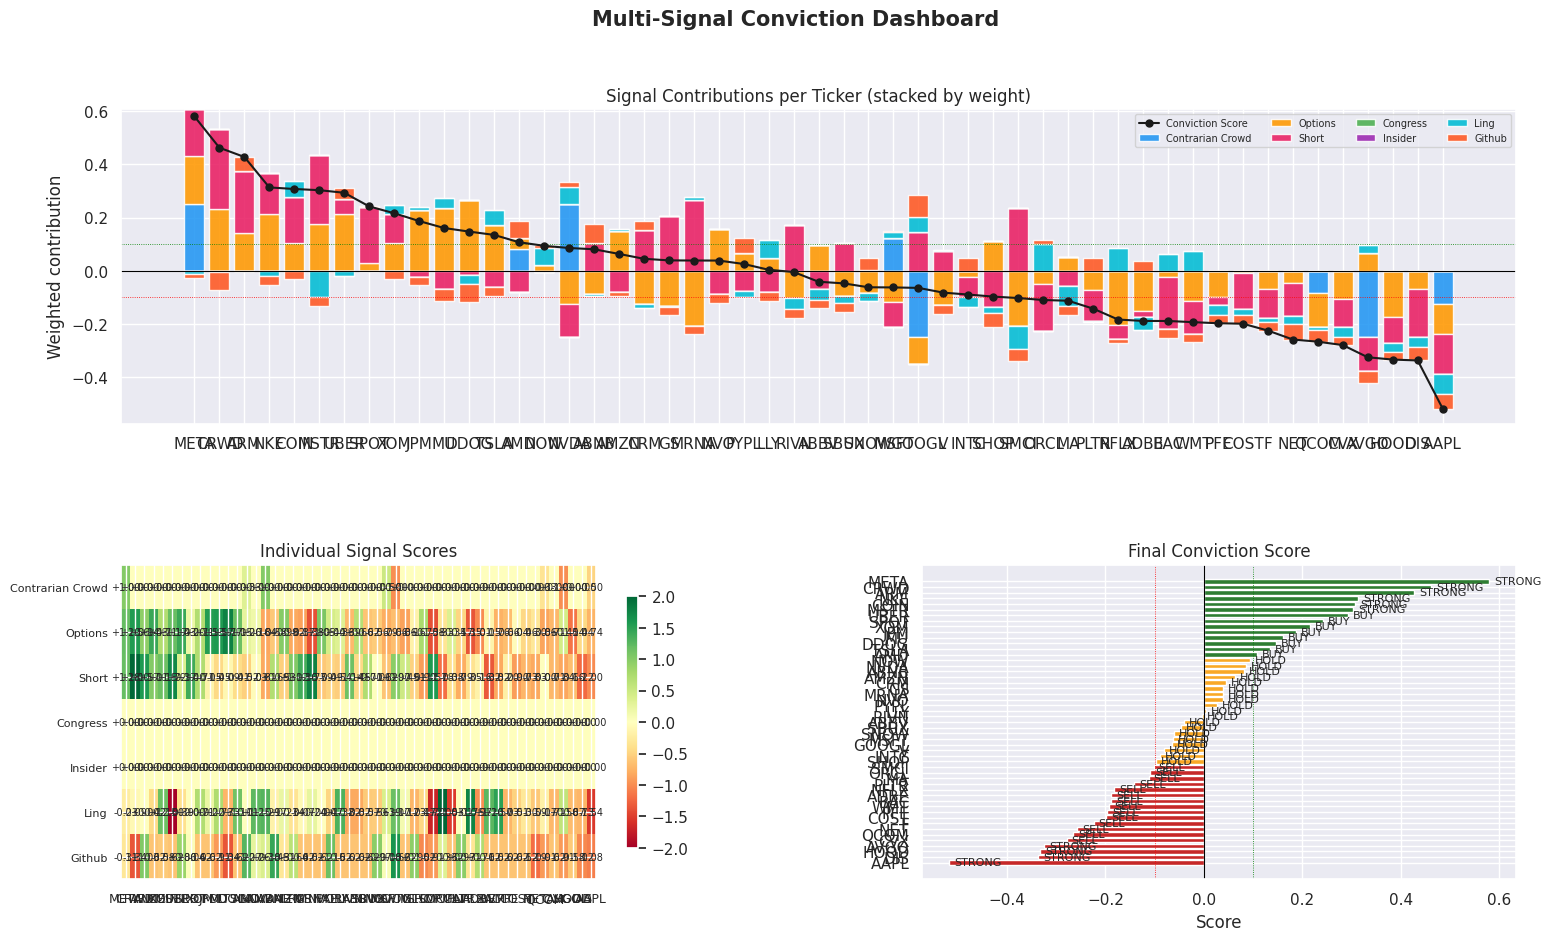

Multi-signal dashboard saved.


In [25]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(18, 10))
fig.suptitle('Multi-Signal Conviction Dashboard', fontsize=15, fontweight='bold')
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

COLORS = ['#2196F3','#FF9800','#E91E63','#4CAF50','#9C27B0','#00BCD4','#FF5722']
sig_cols = [c for c in SIGNAL_WEIGHTS if c in sig_df.columns]

# ── Stacked bar: signal contributions ────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
bot_pos = np.zeros(len(sig_df))
bot_neg = np.zeros(len(sig_df))
for i, col in enumerate(sig_cols):
    w    = SIGNAL_WEIGHTS[col]
    vals = sig_df[col].fillna(0).values * w
    pos  = np.where(vals >= 0, vals, 0)
    neg  = np.where(vals <  0, vals, 0)
    lbl  = col.replace('_signal','').replace('_',' ').title()
    ax1.bar(sig_df.index, pos, bottom=bot_pos, color=COLORS[i], label=lbl, alpha=0.88)
    ax1.bar(sig_df.index, neg, bottom=bot_neg, color=COLORS[i], alpha=0.88)
    bot_pos += pos
    bot_neg += neg
ax1.plot(sig_df.index, sig_df['conviction'].values, 'ko-', linewidth=1.5,
         markersize=5, label='Conviction Score', zorder=5)
ax1.axhline(0, color='black', linewidth=0.8)
ax1.axhline( 0.1, color='green', linewidth=0.6, linestyle=':')
ax1.axhline(-0.1, color='red',   linewidth=0.6, linestyle=':')
ax1.set_title('Signal Contributions per Ticker (stacked by weight)')
ax1.set_ylabel('Weighted contribution')
ax1.legend(fontsize=7, ncol=4, loc='upper right')

# ── Heatmap of individual signals ────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
heat_data = sig_df[sig_cols].fillna(0).T
im = ax2.imshow(heat_data.values, cmap='RdYlGn', aspect='auto', vmin=-2, vmax=2)
ax2.set_xticks(range(len(sig_df)))
ax2.set_xticklabels(sig_df.index, fontsize=9)
ax2.set_yticks(range(len(sig_cols)))
ax2.set_yticklabels([c.replace('_signal','').replace('_',' ').title()
                     for c in sig_cols], fontsize=8)
for r in range(len(sig_cols)):
    for c in range(len(sig_df)):
        ax2.text(c, r, f'{heat_data.values[r,c]:+.2f}', ha='center',
                 va='center', fontsize=7)
ax2.set_title('Individual Signal Scores')
plt.colorbar(im, ax=ax2, shrink=0.8)

# ── Final conviction bar ──────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
bar_colors = ['#2e7d32' if v > 0.1 else ('#c62828' if v < -0.1 else '#f9a825')
              for v in sig_df['conviction']]
ax3.barh(sig_df.index[::-1], sig_df['conviction'][::-1], color=bar_colors[::-1])
ax3.axvline(0, color='black', linewidth=0.8)
ax3.axvline( 0.1, color='green', linewidth=0.6, linestyle=':')
ax3.axvline(-0.1, color='red',   linewidth=0.6, linestyle=':')
for i, (ticker, row) in enumerate(sig_df[::-1].iterrows()):
    ax3.text(row['conviction'] + 0.01, i, row['recommendation'].split()[0],
             va='center', fontsize=8)
ax3.set_title('Final Conviction Score')
ax3.set_xlabel('Score')

plt.savefig('crowd_investing_multisignal.png', dpi=150, bbox_inches='tight')
plt.show()
print('Multi-signal dashboard saved.')

## 10. Next Steps & Extensions

| Extension | Description |
|-----------|-------------|
| **StockTwits auth** | Register a free app at stocktwits.com/developers for higher rate limits |
| **More tickers** | Expand `TICKERS` list — StockTwits supports any symbol |
| **FinBERT sentiment** | Replace VADER with `ProsusAI/finbert` for higher accuracy on financial text |
| **NewsAPI live** | Set `NEWSAPI_KEY` env var to pull real headlines instead of demo data |
| **Options flow** | Integrate unusual options activity (Unusual Whales API) as a contrarian signal |
| **Short interest** | Finra short volume data as a crowded-short indicator |
| **Earnings calendar** | Suppress signals near earnings dates to avoid event risk |
| **Portfolio optimizer** | Replace equal-weight long/short with mean-variance optimization (cvxpy) |
| **Alerting** | Schedule notebook to run daily and send Slack/email alerts on BUY/SELL signals |
| **Factor attribution** | Regress returns on Fama-French 5 factors to isolate alpha from crowd sentiment |
